### Imports e iniciando cessão com o S3

In [1]:
import pandas as pd 
import boto3 

from dotenv import load_dotenv
from datetime import datetime
from src.data.utils import *

load_dotenv()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandera/_pandas_deprecated.py:144: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


True

In [2]:
session = iniciar_cessao_aws()
s3 = session.client("s3")

BUCKET = os.getenv("BUCKET_NAME")

In [3]:
def listar_apenas_pastas(s3_client, bucket: str):
    paginator = s3_client.get_paginator('list_objects_v2')
    todas_pastas = set()

    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            partes = obj['Key'].split('/')
            if len(partes) > 1:
                # Adiciona o caminho da pasta
                pasta = "/".join(partes[:-1])
                todas_pastas.add(pasta)

    print(f"📁 Pastas encontradas em s3://{bucket}/:\n")
    for pasta in sorted(todas_pastas):
        print(f"- {pasta}")

# Executar:
listar_apenas_pastas(s3, BUCKET)


📁 Pastas encontradas em s3://postech-challenge-datascience-003/:

- bronze/ano=2023/dados
- bronze/ano=2023/dicionario
- bronze/ano=2024/dados
- bronze/ano=2024/dicionario
- bronze/ano=2025/dados
- bronze/ano=2025/dicionario
- gold/ano=dimensao/dados
- gold/ano=historico/dados
- gold/dados_externos
- gold/fato/ano=2026/dados
- gold/modelo
- models
- silver/ano=2023/dados
- silver/ano=2024/dados
- silver/ano=2025/dados
- silver/metadata/ano=2026/dados


In [4]:
prefixo = "gold/dados_externos"

response = s3.list_objects_v2(Bucket=BUCKET,Prefix=prefixo)

if "Contents" in response:
    print(f"Arquivos encontrados em s3://{BUCKET}/{prefixo}:\n")
    for obj in response["Contents"]:
        nome_arquivo = obj['Key'].split('/')[-1]
        nome_arquivo = nome_arquivo.replace(".parquet","")
        tamanho_kb = obj["Size"] / 1024 
        print(f"- {nome_arquivo} ({tamanho_kb:.2f} KB)")
else:
    print(f"Nenhum arquivo encontrado em s3://{BUCKET}/{prefixo}")



Arquivos encontrados em s3://postech-challenge-datascience-003/gold/dados_externos:

-  (0.00 KB)
- analise_municipio (705.43 KB)
- analise_uf (20.16 KB)
- dim_contexto_socioeconomico_uf (7.79 KB)
- fact_escola (3827.88 KB)
- fact_municipio (100.49 KB)
- fact_uf_ano (25.09 KB)
- ranking_prioridade (966.98 KB)


## <font color="green">Leitura S3</font>
![Status AWS](https://img.shields.io/badge/AWS-Dados_Carregados-green?style=for-the-badge&logo=amazonaws)


In [5]:
# 1. Tabelas com partição 'ano=historico'
resultado_metas      = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="RESULTADOS_METAS", ano="historico")
resultado_metas_muni = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="RESULTADOS_METAS_MUNICIPIO", ano="historico")
df_alunos            = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="TS_ALUNO", ano="historico")
df_municipios        = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="TS_MUNICIPIO", ano="historico")
df_estados           = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="TS_ESTADO", ano="historico")



Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/RESULTADOS_METAS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ALUNO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_MUNICIPIO.parquet
Lendo: s3://postech-challenge-datascience-003/gold/ano=historico/dados/TS_ESTADO.parquet


In [6]:

df_meta              = carregar_parquet_s3(s3, BUCKET, camada="gold/fato", nome_tabela="Fato_Alfabetizacao_Meta", ano=2026)
df_alfabetizacao     = carregar_parquet_s3(s3, BUCKET, camada="gold/fato", nome_tabela="FATO_ALFABETIZACAO", ano=2026)



Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/Fato_Alfabetizacao_Meta.parquet
Lendo: s3://postech-challenge-datascience-003/gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet


In [7]:
def carregar_parquet_s3(
    s3_client,
    bucket: str,
    nome_tabela: str,
    camada: str = "gold",
    ano: str | int = None,
    subpasta: str = None,
    ler_dicionario: bool = False,
) -> pd.DataFrame:
    """
    Carrega qualquer arquivo Parquet do S3 de forma flexível.
    
    Exemplos de chaves geradas:
    - Com ano:        'gold/ano=historico/dados/TS_ALUNO.parquet'
    - Dados externos: 'gold/dados_externos/fact_escola.parquet'
    - Fato 2026:      'gold/fato/ano=2026/dados/FATO_ALFABETIZACAO.parquet'
    """
    nome_arquivo = f"dicionario_{nome_tabela}.parquet" if ler_dicionario else f"{nome_tabela}.parquet"
    
    # Montagem dinâmica da chave no S3
    if subpasta:
        # Se você passar uma subpasta direta (ex: 'dados_externos' ou 'fato/ano=2026/dados')
        chave = f"{camada}/{subpasta}/{nome_arquivo}"
    elif ano is not None:
        # Padrão com partição de ano
        pasta_interna = "dicionario" if ler_dicionario else "dados"
        chave = f"{camada}/ano={ano}/{pasta_interna}/{nome_arquivo}"
    else:
        # Padrão direto na camada
        chave = f"{camada}/{nome_arquivo}"

    print(f"Lendo: s3://{bucket}/{chave}")

    try:
        obj = s3_client.get_object(Bucket=bucket, Key=chave)
        return pd.read_parquet(BytesIO(obj["Body"].read()))
    except s3_client.exceptions.NoSuchKey:
        raise FileNotFoundError(f"Arquivo não encontrado:\ns3://{bucket}/{chave}")
    except Exception as e:
        raise RuntimeError(f"Erro ao ler {chave} do bucket {bucket}.\n{e}")



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.base import clone

def projetar_alfabetizacao(
    df_metas: pd.DataFrame,
    modelo=None,
    nome_uf: str = "Brasil",
    anos_treino: list = [2019, 2023],
    meta_2030: float = 80.0,
    plotar: bool = True,
    figsize: tuple = (12, 6)
):
    """
    Projeta taxas de alfabetização com base em um modelo de regressão e compara com as metas oficiais do MEC.

    Parâmetros:
    -----------
    df_metas : pd.DataFrame
        DataFrame com colunas de histórico e metas (ex: resultado_metas).
    modelo : estimador scikit-learn (opcional)
        Instância do modelo (ex: LinearRegression(), Ridge(), SVR(), Pipeline(...)).
        Se None, usa LinearRegression(). Se não estiver treinado, a função treina automaticamente.
    nome_uf : str, default 'Brasil'
        Localidade a ser filtrada na coluna 'NOME_UF'.
    anos_treino : list, default [2019, 2023]
        Anos históricos usados para ajustar o modelo de tendência.
    meta_2030 : float, default 80.0
        Meta fixada para o ano de 2030.
    plotar : bool, default True
        Se True, gera e exibe o gráfico executivo.
    figsize : tuple, default (12, 6)
        Dimensões da figura do gráfico.

    Retorna:
    --------
    dict contendo:
        - 'df_projecao': DataFrame com os anos, projeção, metas e gaps calculados.
        - 'gap_2030': Gap em pontos percentuais para 2030.
        - 'modelo': Instância do modelo ajustado.
        - 'historico': Dicionário com anos e taxas observadas.
    """
    # 1. Filtro da localidade
    dados_uf = df_metas[df_metas["NOME_UF"].str.upper() == nome_uf.upper()]
    if dados_uf.empty:
        raise ValueError(f"Localidade '{nome_uf}' não encontrada na coluna 'NOME_UF'.")
    linha = dados_uf.iloc[0]

    # 2. Extração do Histórico Real
    mapa_historico = {
        2019: float(linha["SAEB_2019"]),
        2021: float(linha["SAEB_2021"]),
        2023: float(linha["PC_ALUNO_ALFABETIZADO"])
    }
    anos_hist = np.array(list(mapa_historico.keys()))
    taxas_hist = np.array(list(mapa_historico.values()))

    # 3. Metas Oficiais MEC (2024 a 2030)
    anos_futuros = np.array([2024, 2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
    metas_mec = np.array([
        float(linha["META_FINAL_2024"]),
        float(linha["META_FINAL_2025"]),
        float(linha["META_FINAL_2026"]),
        float(linha["META_FINAL_2027"]),
        float(linha["META_FINAL_2028"]),
        float(linha["META_FINAL_2029"]),
        float(meta_2030)
    ])

    # 4. Configuração e Ajuste do Modelo
    if modelo is None:
        modelo = LinearRegression()
    else:
        # Clona para não alterar o objeto original externamente
        try:
            modelo = clone(modelo)
        except Exception:
            pass

    # Treina o modelo se ele ainda não foi ajustado
    X_treino = np.array(anos_treino).reshape(-1, 1)
    y_treino = np.array([mapa_historico[ano] for ano in anos_treino])
    
    # Se já tiver sido treinado previamente, mantemos; caso contrário, damos fit
    if not hasattr(modelo, "predict") or hasattr(modelo, "fit"):
        modelo.fit(X_treino, y_treino)

    # 5. Previsão
    projecao_tendencia = modelo.predict(anos_futuros).flatten()
    gap_2030 = metas_mec[-1] - projecao_tendencia[-1]

    # DataFrame com os resultados tabulados
    df_projecao = pd.DataFrame({
        "Ano": anos_futuros.flatten(),
        "Meta_MEC": metas_mec,
        "Projecao": projecao_tendencia,
        "Gap_pp": metas_mec - projecao_tendencia
    })

    # 6. Plotagem (Opcional)
    if plotar:
        nome_modelo = modelo.__class__.__name__
        plt.figure(figsize=figsize)

        # Histórico Real
        plt.plot(anos_hist, taxas_hist, marker='o', color='#1f77b4', lw=2.8, markersize=8, label="Histórico Real (SAEB / INEP)")
        for x, y in zip(anos_hist, taxas_hist):
            plt.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', color='#1f77b4')

        # Meta MEC
        plt.plot(anos_futuros.flatten(), metas_mec, marker='s', color='#2ca02c', linestyle='--', lw=2.2, markersize=7, label="Meta Oficial MEC")
        plt.annotate(f"Meta 2030: {metas_mec[-1]:.0f}%", (2030, metas_mec[-1]), textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', color='#2ca02c')

        # Projeção do Modelo
        plt.plot(anos_futuros.flatten(), projecao_tendencia, marker='^', color='#d62728', linestyle=':', lw=2.2, markersize=7, label=f"Projeção ({nome_modelo})")
        plt.annotate(f"Previsto: {projecao_tendencia[-1]:.1f}%", (2030, projecao_tendencia[-1]), textcoords="offset points", xytext=(0, -18), ha='center', fontweight='bold', color='#d62728')

        # Linha e área de Gap
        plt.axhline(meta_2030, color='darkgreen', linestyle='-', alpha=0.3, lw=1.5)
        plt.fill_between(anos_futuros.flatten(), projecao_tendencia, metas_mec, color='#ff9999', alpha=0.2, label=f"Déficit em 2030 (~{gap_2030:.1f} p.p.)")

        plt.title(f"Projeção da Taxa de Alfabetização: {nome_uf.title()} | Modelo: {nome_modelo}", fontsize=14, fontweight='bold', pad=15)
        plt.xlabel("Ano", fontsize=12)
        plt.ylabel("% Alunos Alfabetizados (2º ano)", fontsize=12)
        plt.xticks(np.arange(2019, 2031, 1))
        plt.ylim(min(min(taxas_hist), min(projecao_tendencia)) - 5, max(max(metas_mec), max(projecao_tendencia)) + 8)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
        plt.tight_layout()
        plt.show()

        print("=" * 60)
        print(f"📊 Relatório de Projeção - {nome_uf.upper()} ({nome_modelo})")
        print("=" * 60)
        print(f"Taxa observada em 2023:        {taxas_hist[-1]:.2f}%")
        print(f"Projeção para 2030:            {projecao_tendencia[-1]:.2f}%")
        print(f"Meta oficial do MEC para 2030: {meta_2030:.2f}%")
        print(f"Gap a ser superado:            {gap_2030:.2f} p.p.")
        print("=" * 60)

    return {
        "df_projecao": df_projecao,
        "gap_2030": gap_2030,
        "modelo": modelo,
        "historico": mapa_historico
    }


def projetar_alfabetizacao_estados(
    df_metas: pd.DataFrame,
    ano_avaliacao: int = 2023,
    ano_inicio: int = 2019,
    ano_alvo: int = 2030,
    meta_corte: float = 80.0,
    ufs_excluir: list = None,
    plotar: bool = True,
    figsize: tuple = (12, 10)
):
    """
    Calcula a projeção da taxa de alfabetização por estado (UF) para um ano-alvo
    com base no ritmo histórico e compara com a meta de corte (ex: 80% do MEC).

    Parâmetros:
    -----------
    df_metas : pd.DataFrame
        DataFrame contendo os dados de avaliação e metas dos estados.
    ano_avaliacao : int, default 2023
        Ano base mais recente da avaliação.
    ano_inicio : int, default 2019
        Ano de início para o cálculo do ritmo anual histórico.
    ano_alvo : int, default 2030
        Ano final da projeção.
    meta_corte : float, default 80.0
        Taxa percentual de corte da meta oficial do MEC.
    ufs_excluir : list, optional
        Lista de siglas de UFs a serem desconsideradas (default: ["SC*"]).
    plotar : bool, default True
        Se True, gera e exibe o gráfico de barras horizontais ordenado.
    figsize : tuple, default (12, 10)
        Dimensões da figura do gráfico.

    Retorna:
    --------
    dict contendo:
        - 'df_ranking': DataFrame com as UFs ordenadas pela projeção, ritmo e gap.
        - 'atingem': Quantidade de estados que atingirão a meta.
        - 'total': Quantidade total de estados válidos analisados.
        - 'pct_atingem': Percentual de estados que atingirão a meta.
    """
    if ufs_excluir is None:
        ufs_excluir = ["SC*"]

    # 1. Filtra registros válidos por estado no ano de avaliação
    df_ufs = df_metas[
        (df_metas["NU_ANO_AVALIACAO"] == ano_avaliacao) &
        (df_metas["SIGLA_UF"].notnull()) &
        (~df_metas["SIGLA_UF"].isin(ufs_excluir))
    ].copy()

    # 2. Cálculo do ritmo anual e projeção
    delta_hist = float(ano_avaliacao - ano_inicio)
    delta_proj = float(ano_alvo - ano_avaliacao)

    col_proj = f"PROJ_{ano_alvo}"
    df_ufs["RITMO_ANUAL"] = (df_ufs["PC_ALUNO_ALFABETIZADO"] - df_ufs["SAEB_2019"]) / delta_hist
    df_ufs[col_proj] = (df_ufs["PC_ALUNO_ALFABETIZADO"] + df_ufs["RITMO_ANUAL"] * delta_proj).clip(lower=0.0, upper=100.0)
    df_ufs["GAP_META"] = meta_corte - df_ufs[col_proj]
    df_ufs["ATINGE_META"] = df_ufs[col_proj] >= meta_corte

    # 3. Ordenação para análise e plotagem
    df_plot = df_ufs.dropna(subset=[col_proj]).sort_values(col_proj, ascending=True).copy()

    atingem = int((df_plot[col_proj] >= meta_corte).sum())
    total = len(df_plot)
    pct_atingem = (atingem / total * 100.0) if total > 0 else 0.0

    # 4. Gráfico de Barras Horizontais
    if plotar and total > 0:
        cores = ["#2ca02c" if val >= meta_corte else "#d62728" for val in df_plot[col_proj]]
        labels_y = df_plot["SIGLA_UF"] + " - " + df_plot["NOME_UF"]

        plt.figure(figsize=figsize)
        barras = plt.barh(labels_y, df_plot[col_proj], color=cores, alpha=0.85)

        # Linha de corte da Meta
        plt.axvline(meta_corte, color="darkgreen", linestyle="--", lw=2, label=f"Meta {ano_alvo} MEC ({meta_corte:.0f}%)")

        # Rótulos com os valores em cada barra
        for barra in barras:
            w = barra.get_width()
            cor_texto = "#2ca02c" if w >= meta_corte else "#b22222"
            plt.text(
                w + 1,
                barra.get_y() + barra.get_height() / 2,
                f"{w:.1f}%",
                va='center',
                ha='left',
                fontsize=9,
                fontweight='bold',
                color=cor_texto
            )

        plt.title(f"Projeção da Taxa de Alfabetização por Estado em {ano_alvo} (Ritmo Histórico {ano_inicio}-{ano_avaliacao})", fontsize=14, fontweight='bold', pad=15)
        plt.xlabel(f"% Previsto de Alunos Alfabetizados em {ano_alvo}", fontsize=11)
        plt.xlim(0, 110)
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.legend(loc='lower right', frameon=True)
        plt.tight_layout()
        plt.show()

        print("=" * 70)
        print(f"📊 Panorama Nacional por Estados - Meta {ano_alvo} ({meta_corte:.0f}%)")
        print("=" * 70)
        print(f"Apenas {atingem} de {total} estados ({pct_atingem:.1f}%) atingirão a meta de {meta_corte:.0f}% no ritmo atual.")
        print("=" * 70)

    colunas_retorno = [
        "SIGLA_UF", "NOME_UF", "SAEB_2019", "PC_ALUNO_ALFABETIZADO",
        "RITMO_ANUAL", col_proj, "GAP_META", "ATINGE_META"
    ]
    colunas_existentes = [c for c in colunas_retorno if c in df_plot.columns]

    return {
        "df_ranking": df_plot[colunas_existentes],
        "atingem": atingem,
        "total": total,
        "pct_atingem": pct_atingem
    }


def plotar_importancia_features(
    modelo,
    X: pd.DataFrame = None,
    feature_names: list = None,
    top_n: int = 15,
    titulo: str = None,
    xlabel: str = "Importância",
    cor: str = "#1f77b4",
    plotar: bool = True,
    figsize: tuple = (10, 7)
):
    """
    Calcula, exibe e plota as features mais importantes de um modelo treinado
    (compatível com LightGBM, XGBoost, CatBoost, RandomForest e modelos lineares).

    Parâmetros:
    -----------
    modelo : Estimador treinado (ex: LGBMRegressor, RandomForest, Pipeline, etc.)
    X : pd.DataFrame, optional
        DataFrame com as features de treino/teste para extrair nomes de colunas caso o modelo não tenha.
    feature_names : list, optional
        Lista explícita com os nomes das features.
    top_n : int, default 15
        Quantidade de features mais relevantes a serem plotadas.
    titulo : str, optional
        Título customizado do gráfico.
    xlabel : str, default 'Importância'
        Legenda do eixo X.
    cor : str, default '#1f77b4'
        Cor das barras do gráfico.
    plotar : bool, default True
        Se True, gera e exibe o gráfico de barras horizontais.
    figsize : tuple, default (10, 7)
        Dimensões da figura do gráfico.

    Retorna:
    --------
    pd.Series ordenada de forma decrescente com as importâncias de todas as features.
    """
    # 1. Se for Pipeline do scikit-learn, extrai o estimador final
    estimador = modelo
    if hasattr(modelo, "steps"):
        estimador = modelo.steps[-1][1]

    # 2. Extração dos pesos / importâncias
    if hasattr(estimador, "feature_importances_"):
        importancias_raw = estimador.feature_importances_
    elif hasattr(estimador, "coef_"):
        importancias_raw = np.abs(estimador.coef_).flatten()
    else:
        raise AttributeError("O modelo fornecido não possui 'feature_importances_' nem 'coef_'.")

    # 3. Resolução dos nomes das features
    if feature_names is not None:
        nomes = list(feature_names)
    elif hasattr(estimador, "feature_name_"):  # Padrão LightGBM
        nomes = list(estimador.feature_name_)
    elif hasattr(estimador, "feature_names_in_"):  # Padrão Scikit-Learn 1.0+
        nomes = list(estimador.feature_names_in_)
    elif X is not None and hasattr(X, "columns"):
        nomes = list(X.columns)
    else:
        nomes = [f"feature_{i}" for i in range(len(importancias_raw))]

    # 4. Criação da Série ordenada
    importancias = pd.Series(importancias_raw, index=nomes).sort_values(ascending=False)

    # 5. Gráfico
    if plotar:
        top_features = importancias.head(top_n)
        nome_modelo = estimador.__class__.__name__

        plt.figure(figsize=figsize)
        ax = top_features.plot(kind="barh", color=cor, alpha=0.85)
        plt.gca().invert_yaxis()

        # Rótulos de texto com os valores nas barras
        max_val = top_features.max()
        offset = max_val * 0.01 if max_val > 0 else 0.1

        for i, val in enumerate(top_features):
            texto = f" {val:.0f}" if val >= 100 else f" {val:.2f}"
            ax.text(val + offset, i, texto, va='center', ha='left', fontsize=9, fontweight='bold', color='#333333')

        titulo_final = titulo or f"Top {min(top_n, len(top_features))} Features Mais Importantes - {nome_modelo}"
        plt.title(titulo_final, fontsize=13, fontweight='bold', pad=12)
        plt.xlabel(xlabel, fontsize=11)
        plt.xlim(0, max_val * 1.12 if max_val > 0 else 1)
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        print(f"📌 Top {min(top_n, len(top_features))} Features:")
        print(top_features)

    return importancias


import os
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def carregar_modelo(nome_ou_caminho: str):
    """
    Carrega um modelo salvo em formato .joblib de forma resiliente.
    Busca automaticamente em múltiplos diretórios (raiz, models/, notebooks/models/).

    Parâmetros:
    -----------
    nome_ou_caminho : str
        Nome do arquivo (ex: 'modelo_lgbm_profundo.joblib') ou caminho relativo/absoluto.

    Retorna:
    --------
    Objeto do modelo carregado via joblib.
    """
    import joblib

    p = Path(nome_ou_caminho)
    # Se não tiver extensão, adiciona .joblib
    if not p.suffix:
        p = p.with_suffix(".joblib")

    # Lista de caminhos potenciais
    candidatos = [
        p,
        Path("models") / p.name,
        Path("notebooks/models") / p.name,
        Path("../models") / p.name,
        Path.cwd() / p,
        Path.cwd().parent / "models" / p.name,
    ]

    for cand in candidatos:
        if cand.exists() and cand.is_file():
            print(f"📦 Modelo carregado com sucesso de: {cand.resolve()}")
            return joblib.load(cand)

    raise FileNotFoundError(
        f"Não foi possível encontrar o arquivo '{nome_ou_caminho}'.\n"
        f"Tentativas verificadas:\n" + "\n".join([f" - {c.resolve()}" for c in candidatos])
    )


def salvar_modelo(modelo, nome_arquivo: str, pasta: str = "models"):
    """
    Salva um modelo treinado usando joblib, criando o diretório se necessário.

    Parâmetros:
    -----------
    modelo : estimador scikit-learn / lightgbm / etc.
    nome_arquivo : str
        Nome do arquivo (ex: 'modelo_lgbm_profundo.joblib').
    pasta : str, default 'models'
        Diretório onde o modelo será salvo.

    Retorna:
    --------
    Path do arquivo salvo.
    """
    import joblib

    p_pasta = Path(pasta)
    p_pasta.mkdir(parents=True, exist_ok=True)

    if not nome_arquivo.endswith(".joblib"):
        nome_arquivo += ".joblib"

    destino = p_pasta / nome_arquivo
    joblib.dump(modelo, destino)
    print(f"💾 Modelo salvo com sucesso em: {destino.resolve()}")
    return destino


def fazer_previsoes(
    modelo_ou_caminho,
    X,
    y_true=None,
    plotar: bool = True,
    figsize: tuple = (8, 6)
):
    """
    Gera previsões a partir de um modelo (ou caminho para o .joblib) e,
    caso os valores reais (y_true) sejam fornecidos, calcula métricas de erro
    (RMSE, MAE, R², MAPE) e plota o gráfico de Real vs Previsto.

    Parâmetros:
    -----------
    modelo_ou_caminho : Estimador ou str
        Instância do modelo carregado ou string com o caminho/nome do arquivo .joblib.
    X : pd.DataFrame ou np.ndarray
        Features de entrada para previsão (ex: X_test).
    y_true : pd.Series ou np.ndarray, optional
        Valores reais observados (ex: y_test) para validação.
    plotar : bool, default True
        Se True e y_true for fornecido, plota o gráfico de dispersão Real vs Previsto.
    figsize : tuple, default (8, 6)
        Tamanho da figura do gráfico.

    Retorna:
    --------
    dict contendo:
        - 'y_pred': Array com as previsões geradas.
        - 'df_resultados': DataFrame comparando Real, Previsto e Erro (se y_true informado).
        - 'metricas': Dicionário com RMSE, MAE, R2 e MAPE (se y_true informado).
        - 'modelo': Instância do modelo utilizado.
    """
    # 1. Carrega o modelo se for passado como caminho de texto
    if isinstance(modelo_ou_caminho, (str, Path)):
        modelo = carregar_modelo(str(modelo_ou_caminho))
    else:
        modelo = modelo_ou_caminho

    # 2. Faz as previsões
    y_pred = modelo.predict(X)
    if hasattr(y_pred, "flatten"):
        y_pred = y_pred.flatten()

    resultados = {
        "y_pred": y_pred,
        "modelo": modelo,
        "metricas": None,
        "df_resultados": None
    }

    # 3. Avaliação de Desempenho (caso y_true seja fornecido)
    if y_true is not None:
        y_val = np.array(y_true).flatten()

        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        mape = np.mean(np.abs((y_val - y_pred) / np.where(y_val == 0, 1e-6, y_val))) * 100

        metricas = {
            "RMSE": float(rmse),
            "MAE": float(mae),
            "R2": float(r2),
            "MAPE(%)": float(mape)
        }

        # DataFrame tabulado
        df_comp = pd.DataFrame({
            "Real": y_val,
            "Previsto": y_pred,
            "Erro_Absoluto": np.abs(y_val - y_pred),
            "Erro_Residual": y_val - y_pred
        })

        resultados["metricas"] = metricas
        resultados["df_resultados"] = df_comp

        print("=" * 55)
        print("🎯 Relatório de Desempenho do Modelo")
        print("=" * 55)
        print(f"R² Score: {r2:.4f}")
        print(f"RMSE:     {rmse:.4f}")
        print(f"MAE:      {mae:.4f}")
        print(f"MAPE:     {mape:.2f}%")
        print("=" * 55)

        # 4. Gráfico Real vs Previsto
        if plotar:
            plt.figure(figsize=figsize)
            plt.scatter(y_val, y_pred, alpha=0.6, color="#1f77b4", edgecolor='k', s=35, label="Observações")

            # Linha diagonal ideal (y = x)
            min_val = min(y_val.min(), y_pred.min())
            max_val = max(y_val.max(), y_pred.max())
            plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', lw=2, label="Previsão Ideal (y = x)")

            nome_mod = modelo.__class__.__name__
            plt.title(f"Validação: Real vs Previsto ({nome_mod})", fontsize=13, fontweight='bold', pad=12)
            plt.xlabel("Valor Real (y_true)", fontsize=11)
            plt.ylabel("Valor Previsto (y_pred)", fontsize=11)
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.legend(loc="upper left")
            plt.tight_layout()
            plt.show()

    else:
        print(f"✅ {len(y_pred)} previsões geradas com sucesso!")

    return resultados





In [8]:
df_fact_escola       = carregar_parquet_s3(s3, BUCKET, camada="gold", nome_tabela="fact_escola", subpasta="dados_externos")


Lendo: s3://postech-challenge-datascience-003/gold/dados_externos/fact_escola.parquet


## <font color="green">Enriquecendo a tabela dos Alunos </font>

A analise exploratória e enriquecimento foi feito por todos os integrandes do grupo, em notebooks diferentes

 <font color="#FF9900">Começamos Padronizando a prévia de nomes de colunas de metas </font>

In [9]:
resultado_metas_muni = resultado_metas_muni.rename(columns={'ANO': 'NU_ANO_AVALIACAO'})
resultado_metas = resultado_metas.rename(columns={'ANO': 'NU_ANO_AVALIACAO', 'CD_UF': 'CO_UF'})

# Garantir mesmos tipos numéricos nas chaves
for col in ['NU_ANO_AVALIACAO', 'CO_UF']:
    for df in [df_alunos, df_municipios, df_estados, resultado_metas_muni, resultado_metas]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

if 'CO_MUNICIPIO' in df_alunos.columns and 'CO_MUNICIPIO' in df_municipios.columns:
    df_alunos['CO_MUNICIPIO'] = pd.to_numeric(df_alunos['CO_MUNICIPIO'], errors='coerce')
    df_municipios['CO_MUNICIPIO'] = pd.to_numeric(df_municipios['CO_MUNICIPIO'], errors='coerce')


linhas_iniciais = len(df_alunos)
print(f"Linhas carregadas : {linhas_iniciais}")

Linhas carregadas : 6090791


 <font color="#FF9900"> Então enriqueceremos o TS_ALUNO com dados do MUNICÍPIO (Médias e % Alfabetizados) </font>

In [10]:
# 1. Filtramos pelo TOTAL GERAL do Município (ID_TIPO_REDE == 5)
cols_muni = ['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_muni_total = df_municipios[df_municipios['ID_TIPO_REDE'] == 5][cols_muni].copy()

# 2. Renomeamos para as colunas finais
df_muni_total = df_muni_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_MUNICIPIO',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'
})

# 3. Se a coluna já existia com nulos no df_alunos, removemos ela antes para recriar limpa
cols_existentes_remover = [c for c in ['VL_MEDIA_LP_TOTAL_MUNICIPIO', 'PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO'] if c in df_alunos.columns]
if cols_existentes_remover:
    df_alunos = df_alunos.drop(columns=cols_existentes_remover)

# 4. Fazemos o Merge perfeito
df_alunos = df_alunos.merge(
    df_muni_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
    on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
    how='left'
)

print("✅ Merge concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO:", df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_MUNICIPIO'].isna().mean():.2%}")


✅ Merge concluído com sucesso!
Nulos restantes em VL_MEDIA_LP_TOTAL_MUNICIPIO: 3929
Percentual de nulos: 0.06%


 <font color="#FF9900">Enriquecer TS_ALUNO com dados do ESTADO (UF)</font>

In [11]:
# 1. Selecionamos as colunas e filtramos pelo TOTAL DO ESTADO (ID_TIPO_REDE == 5)
cols_uf = ['NU_ANO_AVALIACAO', 'CO_UF', 'VL_MEDIA_LP', 'PC_ALUNO_ALFABETIZADO']

df_estados_total = df_estados[df_estados['ID_TIPO_REDE'] == 5][cols_uf].copy()

# 2. Renomeamos para os nomes finais desejados
df_estados_total = df_estados_total.rename(columns={
    'VL_MEDIA_LP': 'VL_MEDIA_LP_TOTAL_UF',
    'PC_ALUNO_ALFABETIZADO': 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'
})

# 3. Removemos as colunas antigas com nulos do df_alunos antes de recriar
cols_uf_remover = [c for c in ['VL_MEDIA_LP_TOTAL_UF', 'PC_ALUNO_ALFABETIZADO_TOTAL_UF'] if c in df_alunos.columns]
if cols_uf_remover:
    df_alunos = df_alunos.drop(columns=cols_uf_remover)

# 4. Fazemos o Merge perfeito com o Total do Estado
df_alunos = df_alunos.merge(
    df_estados_total.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
    on=['NU_ANO_AVALIACAO', 'CO_UF'],
    how='left'
)

print("✅ Merge de Estado concluído com sucesso!")
print("Nulos restantes em VL_MEDIA_LP_TOTAL_UF:", df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().sum())
print("Percentual de nulos:", f"{df_alunos['VL_MEDIA_LP_TOTAL_UF'].isna().mean():.2%}")


✅ Merge de Estado concluído com sucesso!
Nulos restantes em VL_MEDIA_LP_TOTAL_UF: 27698
Percentual de nulos: 0.45%


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do MUNICÍPIO</font>

In [12]:
cols_metas_mun = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_MUN_2024', 'META_MUN_2025', 'META_MUN_2026'] if c in resultado_metas_muni.columns]

if cols_metas_mun:
    renomear_metas_mun = {c: c.replace('META_FINAL_', 'META_MUN_') for c in cols_metas_mun}
    df_metas_mun_prep = resultado_metas_muni[['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'] + cols_metas_mun].rename(columns=renomear_metas_mun)
    
    df_alunos = df_alunos.merge(
        df_metas_mun_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO']),
        on=['NU_ANO_AVALIACAO', 'CO_UF', 'CO_MUNICIPIO'],
        how='left'
    )
    print("[SUCESSO] Metas Municipais agregadas!")


[SUCESSO] Metas Municipais agregadas!


 <font color="#FF9900">Enriquecer TS_ALUNO com as METAS do ESTADO (UF)</font>

In [13]:
cols_metas_uf = [c for c in ['META_FINAL_2024', 'META_FINAL_2025', 'META_FINAL_2026', 'META_UF_2024', 'META_UF_2025', 'META_UF_2026'] if c in resultado_metas.columns]

if cols_metas_uf:
    renomear_metas_uf = {c: c.replace('META_FINAL_', 'META_UF_') for c in cols_metas_uf}
    df_metas_uf_prep = resultado_metas[['NU_ANO_AVALIACAO', 'CO_UF'] + cols_metas_uf].rename(columns=renomear_metas_uf)
    
    df_alunos = df_alunos.merge(
        df_metas_uf_prep.drop_duplicates(subset=['NU_ANO_AVALIACAO', 'CO_UF']),
        on=['NU_ANO_AVALIACAO', 'CO_UF'],
        how='left'
    )
    print("[SUCESSO] Metas Estaduais agregadas!")

# Validação Final

print(f"\nLinhas iniciais: {linhas_iniciais} | Linhas finais: {len(df_alunos)}")
print(f"Colunas finais: {df_alunos.shape[1]}")


[SUCESSO] Metas Estaduais agregadas!

Linhas iniciais: 6090791 | Linhas finais: 6090791
Colunas finais: 21


In [14]:
#Remover duplicados 
df_alunos = df_alunos.drop_duplicates()  
print(f'Duplicados removidos da base :  {linhas_iniciais - len(df_alunos)}')

Duplicados removidos da base :  0


# <font color="green">Analise exploratória de Dados</font>

## MODELOS

### <font color="green"> Funções </font>

In [15]:
def avaliar(nome, y_true, y_pred, y_proba=None):
    print(f"\n{'='*45}")
    print(f"  {nome}")
    print(f"{'='*45}")
    print(f"  Acurácia : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precisão : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    if y_proba is not None:
        print(f"  AUC-ROC  : {roc_auc_score(y_true, y_proba):.4f}")



def plot_classificacao(model, X_test, y_test, model_name="Modelo"):
    # Previsões de classe (0 ou 1) e de probabilidade (0.0 a 1.0)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # ── 1. Matriz de Confusão ──
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=["Não Alfabetizado", "Alfabetizado"]
    )
    disp.plot(ax=ax[0], cmap="Blues", values_format="d")
    ax[0].set_title(f"Matriz de Confusão ({model_name})", fontsize=12, weight="bold")
    
    # ── 2. Curva ROC ──
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    score_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {score_auc:.4f})")
    ax[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Aleatório (0.50)")
    ax[1].set_xlabel("Taxa de Falsos Positivos")
    ax[1].set_ylabel("Taxa de Verdadeiros Positivos")
    ax[1].set_title(f"Curva ROC ({model_name})", fontsize=12, weight="bold")
    ax[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

### <font color="green">Feat Engenering</font>

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lightgbm as lgb_lib
import xgboost as xgb_lib
from xgboost import XGBRegressor

from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)



In [17]:
df_modelo = carregar_parquet_s3(s3_client=s3,bucket=BUCKET,nome_tabela="tabela_modelo",subpasta="modelo")

df_modelo.head(5)

Lendo: s3://postech-challenge-datascience-003/gold/modelo/tabela_modelo.parquet


,NU_ANO_AVALIACAO,CO_UF,TP_DEPENDENCIA,IN_PRESENCA_LP,IN_PREENCHIMENTO_LP,IN_ALFABETIZADO,RENDIMENTO_MEDIO_MENSAL_REAIS,RENDA_PERCAPITA_SBENEF_MEDIO,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,ID_ESCOLA,CO_MUNICIPIO
0,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
1,2023,11,3.0,1,1,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
2,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0
3,2023,11,3.0,1,1,1,2916.0,1524.801152,89.593066,60000001.0,1100205.0
4,2023,11,3.0,0,0,0,2916.0,1524.801152,89.593066,60000001.0,1100205.0


Trabalhando as variaveis de REDE  
a utilização do onehot encoder é util para essas variaveis categoricas com poucas variaveis

In [18]:
#  Mapeamento dos códigos 
mapa_dependencia = {
    1: "Federal",
    2: "Estadual",
    3: "Municipal",
    4: "Privada"
}

df_modelo["REDE"] = df_modelo["TP_DEPENDENCIA"].map(mapa_dependencia)

#Instancia o OneHotEncoder (sparse_output=False já entrega um array normal em vez de matriz esparsa)
cat_encoder = OneHotEncoder(sparse_output=False, dtype=int)
# fit_transform  
rede_1hot = cat_encoder.fit_transform(df_modelo[["REDE"]])

# Transformar as categorias em um dataframe
colunas_nomes = cat_encoder.get_feature_names_out(["REDE"])
df_rede_1hot = pd.DataFrame(rede_1hot, columns=colunas_nomes, index=df_modelo.index)
# agregar as novas tabelas ao dataframe 
df_modelo = pd.concat([df_modelo, df_rede_1hot], axis=1)

print("✅ Colunas criadas pelo OneHotEncoder:")
display(df_modelo[colunas_nomes].head())

✅ Colunas criadas pelo OneHotEncoder:


,REDE_Estadual,REDE_Municipal,REDE_Privada
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


Criando as features para a escola

In [19]:
# Indicadores Individuais e de Test-Taking 
df_modelo["IN_AUSENTE"] = (df_modelo["IN_PRESENCA_LP"] == 0).astype("int8")

# Features da Escola (Porte, Absenteísmo, Engajamento)
if "ID_ESCOLA" in df_modelo.columns:
    df_modelo["porte_escola_alunos"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_PRESENCA_LP"].transform("count")
    )
    df_modelo["taxa_absenteismo_escola"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_AUSENTE"].transform("mean")
    )
    df_modelo["taxa_preenchimento_escola"] = (
        df_modelo.groupby("ID_ESCOLA")["IN_PREENCHIMENTO_LP"].transform("mean")
    )


#Normalizando a frequencia escolar da escola
df_modelo["freq_escolar_norm"] = df_modelo["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] / 100.0


# Features do Município

if "CO_MUNICIPIO" in df_modelo.columns:
    df_modelo["porte_muni_alunos"] = (
        df_modelo.groupby("CO_MUNICIPIO")["IN_PRESENCA_LP"].transform("count")
    )
    df_modelo["taxa_absenteismo_muni"] = (
        df_modelo.groupby("CO_MUNICIPIO")["IN_AUSENTE"].transform("mean")
    )



#Features Socioeconômicas Relativas, utilizarei o Z-Score para normalizar os dados, dentro da média e o desvio padrão do ano especifico   

# Instancia o scaler
scaler = StandardScaler()

# fit_transform na coluna de renda 

df_modelo["RENDA_ZSCORE_ANO"] = (
    df_modelo.groupby("NU_ANO_AVALIACAO")["RENDA_PERCAPITA_SBENEF_MEDIO"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

print("Média do Z-score:", df_modelo["RENDA_ZSCORE_ANO"].mean().round(4))  # Fica exatamente 0.0
print("Desvio padrão  :", df_modelo["RENDA_ZSCORE_ANO"].std().round(4))   # Fica exatamente 1.0



#Features de região 

mapa_co_uf_regiao = {
    11: "Norte", 12: "Norte", 13: "Norte", 14: "Norte", 15: "Norte", 16: "Norte", 17: "Norte",
    21: "Nordeste", 22: "Nordeste", 23: "Nordeste", 24: "Nordeste", 25: "Nordeste", 26: "Nordeste", 27: "Nordeste", 28: "Nordeste", 29: "Nordeste",
    31: "Sudeste", 32: "Sudeste", 33: "Sudeste", 35: "Sudeste",
    41: "Sul", 42: "Sul", 43: "Sul",
    50: "Centro-Oeste", 51: "Centro-Oeste", 52: "Centro-Oeste", 53: "Centro-Oeste"
}
if "CO_UF" in df_modelo.columns:
    df_modelo["REGIAO"] = df_modelo["CO_UF"].map(mapa_co_uf_regiao)

# One-Hot Encoding da REGIAO
df_regiao_1hot = pd.get_dummies(df_modelo["REGIAO"], prefix="REGIAO", dtype="int8")
df_modelo = pd.concat([df_modelo, df_regiao_1hot], axis=1)


# Normalização Logarítmica nos portes de escola e município
df_modelo["log_porte_escola"] = np.log1p(df_modelo["porte_escola_alunos"])
df_modelo["log_porte_muni"]   = np.log1p(df_modelo["porte_muni_alunos"])

Média do Z-score: -0.0
Desvio padrão  : 1.0


In [20]:
# features que serão selecionadas, ficaremos com as já tratadas e normalizadas 
features = [
    #TARGET
    "IN_ALFABETIZADO" ,
    # Nível Escola
    "taxa_absenteismo_escola",
    "log_porte_escola",
    
    # Nível Município
    "taxa_absenteismo_muni",
    "log_porte_muni",
    
    # Nível Rede (Dummies)
    "REDE_Estadual",
    "REDE_Municipal",
    "REDE_Privada",
    
    # Nível Socioeconômico e Geográfico
    "RENDA_ZSCORE_ANO",
    "freq_escolar_norm",
    
    # Regiões (Dummies)
    "REGIAO_Centro-Oeste",
    "REGIAO_Nordeste",
    "REGIAO_Norte",
    "REGIAO_Sudeste",
    "REGIAO_Sul"
]


### <font color="green"> Treino </font>

#Criando os datasets de treino e teste
#v1 - versao anterior - desabilitada pq náo considera o historico

df_treino = df_modelo[features].copy()

y = df_treino['IN_ALFABETIZADO']
X = df_treino.drop(columns=['IN_ALFABETIZADO'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% teste
    random_state=42  # reprodutibilidade
)

In [21]:
# Criando os datasets de treino e teste
#v2
# Separação temporal
df_treino = df_modelo[df_modelo["NU_ANO_AVALIACAO"] == 2023].copy()
df_validacao = df_modelo[df_modelo["NU_ANO_AVALIACAO"] == 2024].copy()
df_teste = df_modelo[df_modelo["NU_ANO_AVALIACAO"] == 2025].copy()

X_train = df_treino[features].drop(columns=["IN_ALFABETIZADO"])
y_train = df_treino["IN_ALFABETIZADO"]

X_val = df_validacao[features].drop(columns=["IN_ALFABETIZADO"])
y_val = df_validacao["IN_ALFABETIZADO"]

X_test = df_teste[features].drop(columns=["IN_ALFABETIZADO"])
y_test = df_teste["IN_ALFABETIZADO"]

In [22]:
# Random Forest Classifier com RandomizedSearchCV para otimização de hiperparâmetros
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Espaço de busca dos melhores hiperparâmetros
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.7, 0.8]
}

rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [8, 12, ...], 'max_features': ['sqrt', 0.7, ...], 'min_samples_leaf': [5, 10, ...], 'min_samples_split': [10, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function w

In [23]:
rf = RandomForestClassifier(
    **random_search.best_params_,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [24]:
y_pred_proba_val = rf.predict_proba(X_val)[:, 1]

auc_val = roc_auc_score(y_val, y_pred_proba_val)

print(f"AUC validação 2024: {auc_val:.4f}")

AUC validação 2024: 0.6372


In [25]:
#teste com 2025
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

auc_test = roc_auc_score(y_test, y_pred_proba_rf)

print(f"AUC teste 2025: {auc_test:.4f}")

AUC teste 2025: 0.6142


In [26]:
print(f"AUC validação 2024: {auc_val:.4f}")
print(f"AUC teste 2025: {auc_test:.4f}")

AUC validação 2024: 0.6372
AUC teste 2025: 0.6142


In [27]:
# verificando leakege
df_modelo.groupby("ID_ESCOLA")["IN_AUSENTE"].transform("mean")

0          0.309322
1          0.309322
2          0.309322
3          0.309322
4          0.309322
             ...   
6090158    0.037500
6090159    0.240000
6090160    0.152381
6090161    0.500000
6090162    0.152263
Name: IN_AUSENTE, Length: 6090163, dtype: float64

In [28]:
# Ordenar por ano
df_modelo = df_modelo.sort_values(
    ["ID_ESCOLA", "NU_ANO_AVALIACAO"]
)

# Taxa histórica de ausência da escola
df_modelo["taxa_absenteismo_escola_hist"] = (
    df_modelo
    .groupby("ID_ESCOLA")["IN_AUSENTE"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

In [29]:
# Taxa de ausência e porte da escola por ano
hist_escola = (
    df_modelo
    .groupby(["ID_ESCOLA", "NU_ANO_AVALIACAO"])
    .agg(
        taxa_absenteismo_escola=("IN_AUSENTE", "mean"),
        porte_escola_alunos=("IN_PRESENCA_LP", "count")
    )
    .reset_index()
)

hist_escola.head()

,ID_ESCOLA,NU_ANO_AVALIACAO,taxa_absenteismo_escola,porte_escola_alunos
0,60000001.0,2023,0.329114,79
1,60000001.0,2024,0.181818,77
2,60000001.0,2025,0.412500,80
3,60000002.0,2023,0.087379,103
4,60000002.0,2024,0.030000,100


In [30]:
hist_escola = hist_escola.sort_values(
    ["ID_ESCOLA", "NU_ANO_AVALIACAO"]
)

hist_escola["taxa_absenteismo_escola_hist"] = (
    hist_escola
    .groupby("ID_ESCOLA")["taxa_absenteismo_escola"]
    .shift(1)
)

hist_escola["porte_escola_hist"] = (
    hist_escola
    .groupby("ID_ESCOLA")["porte_escola_alunos"]
    .shift(1)
)

In [31]:
hist_muni = (
    df_modelo
    .groupby(["CO_MUNICIPIO", "NU_ANO_AVALIACAO"])
    .agg(
        taxa_absenteismo_muni=("IN_AUSENTE", "mean"),
        porte_muni_alunos=("IN_PRESENCA_LP", "count")
    )
    .reset_index()
)

hist_muni = hist_muni.sort_values(
    ["CO_MUNICIPIO", "NU_ANO_AVALIACAO"]
)

hist_muni["taxa_absenteismo_muni_hist"] = (
    hist_muni
    .groupby("CO_MUNICIPIO")["taxa_absenteismo_muni"]
    .shift(1)
)

hist_muni["porte_muni_hist"] = (
    hist_muni
    .groupby("CO_MUNICIPIO")["porte_muni_alunos"]
    .shift(1)
)

In [32]:
df_modelo = df_modelo.merge(
    hist_escola[
        [
            "ID_ESCOLA",
            "NU_ANO_AVALIACAO",
            "taxa_absenteismo_escola_hist",
            "porte_escola_hist"
        ]
    ],
    on=["ID_ESCOLA", "NU_ANO_AVALIACAO"],
    how="left"
)

df_modelo = df_modelo.merge(
    hist_muni[
        [
            "CO_MUNICIPIO",
            "NU_ANO_AVALIACAO",
            "taxa_absenteismo_muni_hist",
            "porte_muni_hist"
        ]
    ],
    on=["CO_MUNICIPIO", "NU_ANO_AVALIACAO"],
    how="left"
)

In [33]:
features = [
    "IN_ALFABETIZADO",

    # Escola
    "taxa_absenteismo_escola_hist",
    "porte_escola_hist",

    # Município
    "taxa_absenteismo_muni_hist",
    "porte_muni_hist",

    # Rede
    "REDE_Estadual",
    "REDE_Municipal",
    "REDE_Privada",

    # Socioeconômico / geográfico
    "RENDA_ZSCORE_ANO",
    "freq_escolar_norm",

    # Região
    "REGIAO_Centro-Oeste",
    "REGIAO_Nordeste",
    "REGIAO_Norte",
    "REGIAO_Sudeste",
    "REGIAO_Sul"
]

In [34]:
df_treino = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2023
].copy()

df_val = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2024
].copy()

df_teste = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2025
].copy()

In [35]:
TARGET = "IN_ALFABETIZADO"

In [36]:
X_train = df_treino.drop(columns=[TARGET])
y_train = df_treino[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_teste.drop(columns=[TARGET])
y_test = df_teste[TARGET]

In [37]:
print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (1747439, 35) (1747439,)
Validação: (2120560, 35) (2120560,)
Teste: (2222164, 35) (2222164,)


In [38]:
df_modelo.columns.tolist()

['NU_ANO_AVALIACAO',
 'CO_UF',
 'TP_DEPENDENCIA',
 'IN_PRESENCA_LP',
 'IN_PREENCHIMENTO_LP',
 'IN_ALFABETIZADO',
 'RENDIMENTO_MEDIO_MENSAL_REAIS',
 'RENDA_PERCAPITA_SBENEF_MEDIO',
 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT',
 'ID_ESCOLA',
 'CO_MUNICIPIO',
 'REDE',
 'REDE_Estadual',
 'REDE_Municipal',
 'REDE_Privada',
 'IN_AUSENTE',
 'porte_escola_alunos',
 'taxa_absenteismo_escola',
 'taxa_preenchimento_escola',
 'freq_escolar_norm',
 'porte_muni_alunos',
 'taxa_absenteismo_muni',
 'RENDA_ZSCORE_ANO',
 'REGIAO',
 'REGIAO_Centro-Oeste',
 'REGIAO_Nordeste',
 'REGIAO_Norte',
 'REGIAO_Sudeste',
 'REGIAO_Sul',
 'log_porte_escola',
 'log_porte_muni',
 'taxa_absenteismo_escola_hist_x',
 'taxa_absenteismo_escola_hist_y',
 'porte_escola_hist',
 'taxa_absenteismo_muni_hist',
 'porte_muni_hist']

In [39]:
df_modelo[
    [
        "ID_ESCOLA",
        "NU_ANO_AVALIACAO",
        "taxa_absenteismo_escola_hist_x",
        "taxa_absenteismo_escola_hist_y"
    ]
].head(20)

,ID_ESCOLA,NU_ANO_AVALIACAO,taxa_absenteismo_escola_hist_x,taxa_absenteismo_escola_hist_y
0,60000001.0,2023,NaN,NaN
1,60000001.0,2023,1.000000,NaN
2,60000001.0,2023,0.500000,NaN
3,60000001.0,2023,0.666667,NaN
4,60000001.0,2023,0.500000,NaN
5,60000001.0,2023,0.600000,NaN
6,60000001.0,2023,0.500000,NaN
7,60000001.0,2023,0.428571,NaN
8,60000001.0,2023,0.500000,NaN
9,60000001.0,2023,0.444444,NaN


In [40]:
df_modelo[
    [
        "taxa_absenteismo_escola_hist_x",
        "taxa_absenteismo_escola_hist_y"
    ]
].describe()

,taxa_absenteismo_escola_hist_x,taxa_absenteismo_escola_hist_y
count,6.046519e+06,3.856307e+06
mean,1.313551e-01,1.289582e-01
std,1.067203e-01,1.221256e-01
min,0.000000e+00,0.000000e+00
25%,6.481481e-02,5.154639e-02
50%,1.142857e-01,1.052632e-01
75%,1.742424e-01,1.764706e-01
max,1.000000e+00,1.000000e+00


In [41]:
df_modelo = df_modelo.drop(
    columns=[
        "taxa_absenteismo_escola_hist_x",
        "taxa_absenteismo_escola_hist_y"
    ]
)

In [42]:
df_modelo[
    [
        "NU_ANO_AVALIACAO",
        "porte_escola_hist",
        "taxa_absenteismo_muni_hist",
        "porte_muni_hist"
    ]
].groupby("NU_ANO_AVALIACAO").agg(
    ["count", "mean"]
)

porte_escola_hist            taxa_absenteismo_muni_hist  \
                             count       mean                      count   
NU_ANO_AVALIACAO                                                           
2023                             0        NaN                          0   
2024                       1694104  50.014020                    1636118   
2025                       2162203  53.308538                    2210585   

                           porte_muni_hist               
                      mean           count         mean  
NU_ANO_AVALIACAO                                         
2023                   NaN               0          NaN  
2024              0.139265         1636118  4963.349922  
2025              0.124942         2210585  9698.938251

In [43]:
hist_escola = (
    df_modelo
    .groupby(["ID_ESCOLA", "NU_ANO_AVALIACAO"])
    .agg(
        taxa_absenteismo_escola=("IN_AUSENTE", "mean")
    )
    .reset_index()
)

hist_escola = hist_escola.sort_values(
    ["ID_ESCOLA", "NU_ANO_AVALIACAO"]
)

hist_escola["taxa_absenteismo_escola_hist"] = (
    hist_escola
    .groupby("ID_ESCOLA")["taxa_absenteismo_escola"]
    .shift(1)
)


In [44]:
df_modelo = df_modelo.merge(
    hist_escola[
        [
            "ID_ESCOLA",
            "NU_ANO_AVALIACAO",
            "taxa_absenteismo_escola_hist"
        ]
    ],
    on=["ID_ESCOLA", "NU_ANO_AVALIACAO"],
    how="left"
)

In [45]:
df_modelo.groupby("NU_ANO_AVALIACAO")[
    "taxa_absenteismo_escola_hist"
].agg(["count", "mean"])

,count,mean
NU_ANO_AVALIACAO,,
2023,0,NaN
2024,1694104,0.138247
2025,2162203,0.121680


In [46]:
features_rf = [
    "CO_UF",
    "TP_DEPENDENCIA",
    "RENDIMENTO_MEDIO_MENSAL_REAIS",
    "RENDA_PERCAPITA_SBENEF_MEDIO",
    "UF_TAXA_FREQ_LIQUIDA_FUND_PCT",
    "REDE_Estadual",
    "REDE_Municipal",
    "REDE_Privada",
    "freq_escolar_norm",
    "RENDA_ZSCORE_ANO",
    "REGIAO_Centro-Oeste",
    "REGIAO_Nordeste",
    "REGIAO_Norte",
    "REGIAO_Sudeste",
    "REGIAO_Sul",
    "taxa_absenteismo_escola_hist",
    "porte_escola_hist",
    "taxa_absenteismo_muni_hist",
    "porte_muni_hist"
]

TARGET = "IN_ALFABETIZADO"

In [47]:
df_treino = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2023
].copy()

df_val = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2024
].copy()

df_teste = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2025
].copy()

In [48]:
print("taxa histórica está em df_treino?", 
      "taxa_absenteismo_escola_hist" in df_treino.columns)

print("taxa histórica está em df_val?", 
      "taxa_absenteismo_escola_hist" in df_val.columns)

print("taxa histórica está em df_teste?", 
      "taxa_absenteismo_escola_hist" in df_teste.columns)

taxa histórica está em df_treino? True
taxa histórica está em df_val? True
taxa histórica está em df_teste? True


In [49]:
X_train = df_treino[features_rf]
y_train = df_treino[TARGET]

X_val = df_val[features_rf]
y_val = df_val[TARGET]

X_test = df_teste[features_rf]
y_test = df_teste[TARGET]

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (1747439, 19)
Validação: (2120560, 19)
Teste: (2222164, 19)


In [50]:
print("Nulos no treino:")
print(X_train.isna().sum().sort_values(ascending=False))

Nulos no treino:
porte_muni_hist                  1747439
taxa_absenteismo_muni_hist       1747439
porte_escola_hist                1747439
taxa_absenteismo_escola_hist     1747439
REGIAO_Centro-Oeste                    0
REGIAO_Sul                             0
REGIAO_Sudeste                         0
REGIAO_Norte                           0
REGIAO_Nordeste                        0
CO_UF                                  0
TP_DEPENDENCIA                         0
freq_escolar_norm                      0
REDE_Privada                           0
REDE_Municipal                         0
REDE_Estadual                          0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT          0
RENDA_PERCAPITA_SBENEF_MEDIO           0
RENDIMENTO_MEDIO_MENSAL_REAIS          0
RENDA_ZSCORE_ANO                       0
dtype: int64


In [51]:
print("\nTipos:")
print(X_train.dtypes)


Tipos:
CO_UF                              int64
TP_DEPENDENCIA                   float64
RENDIMENTO_MEDIO_MENSAL_REAIS    float64
RENDA_PERCAPITA_SBENEF_MEDIO     float64
UF_TAXA_FREQ_LIQUIDA_FUND_PCT    float64
REDE_Estadual                      int64
REDE_Municipal                     int64
REDE_Privada                       int64
freq_escolar_norm                float64
RENDA_ZSCORE_ANO                 float64
REGIAO_Centro-Oeste                 int8
REGIAO_Nordeste                     int8
REGIAO_Norte                        int8
REGIAO_Sudeste                      int8
REGIAO_Sul                          int8
taxa_absenteismo_escola_hist     float64
porte_escola_hist                float64
taxa_absenteismo_muni_hist       float64
porte_muni_hist                  float64
dtype: object


In [52]:
#distribuição do target:
print("\nProporção de alfabetizados:")
print("2023:", y_train.mean())
print("2024:", y_val.mean())
print("2025:", y_test.mean())


Proporção de alfabetizados:
2023: 0.5021216763503619
2024: 0.5220880333496812
2025: 0.5862236090585573


In [53]:
print("Nulos no treino:")
print(X_train.isna().sum().sort_values(ascending=False))

Nulos no treino:
porte_muni_hist                  1747439
taxa_absenteismo_muni_hist       1747439
porte_escola_hist                1747439
taxa_absenteismo_escola_hist     1747439
REGIAO_Centro-Oeste                    0
REGIAO_Sul                             0
REGIAO_Sudeste                         0
REGIAO_Norte                           0
REGIAO_Nordeste                        0
CO_UF                                  0
TP_DEPENDENCIA                         0
freq_escolar_norm                      0
REDE_Privada                           0
REDE_Municipal                         0
REDE_Estadual                          0
UF_TAXA_FREQ_LIQUIDA_FUND_PCT          0
RENDA_PERCAPITA_SBENEF_MEDIO           0
RENDIMENTO_MEDIO_MENSAL_REAIS          0
RENDA_ZSCORE_ANO                       0
dtype: int64


In [54]:
print("\nTipos das features:")
print(X_train.dtypes)


Tipos das features:
CO_UF                              int64
TP_DEPENDENCIA                   float64
RENDIMENTO_MEDIO_MENSAL_REAIS    float64
RENDA_PERCAPITA_SBENEF_MEDIO     float64
UF_TAXA_FREQ_LIQUIDA_FUND_PCT    float64
REDE_Estadual                      int64
REDE_Municipal                     int64
REDE_Privada                       int64
freq_escolar_norm                float64
RENDA_ZSCORE_ANO                 float64
REGIAO_Centro-Oeste                 int8
REGIAO_Nordeste                     int8
REGIAO_Norte                        int8
REGIAO_Sudeste                      int8
REGIAO_Sul                          int8
taxa_absenteismo_escola_hist     float64
porte_escola_hist                float64
taxa_absenteismo_muni_hist       float64
porte_muni_hist                  float64
dtype: object


desprezar o 2023 como treino e ir para 2024

In [55]:
df_treino = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2024
].copy()

df_teste = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2025
].copy()

In [56]:
X_train = df_treino[features_rf]
y_train = df_treino[TARGET]

X_test = df_teste[features_rf]
y_test = df_teste[TARGET]

In [57]:
print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (2120560, 19) (2120560,)
Teste: (2222164, 19) (2222164,)


In [58]:
# treinar o modelo Random Forest com os hiperparâmetros encontrados anteriormente
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [59]:
# previsão de 2025
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [60]:
#calculo das métricas:
print("Random Forest — Teste 2025")
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

Random Forest — Teste 2025
Acurácia:  0.5960
Precisão:  0.6364
Recall:    0.7250
F1:        0.6778
AUC-ROC:   0.6186

Matriz de confusão:
[[379820 539659]
 [358188 944497]]


In [61]:
random_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 10,
 'max_features': 'sqrt',
 'max_depth': 8}

verdadeiros positivos: 944.497
falsos positivos: 539.659
verdadeiros negativos: 379.820
falsos negativos: 358.188

In [62]:
# Random Forest Classifier com RandomizedSearchCV para otimização de hiperparâmetros
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Espaço de busca dos melhores hiperparâmetros
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.7, 0.8]
}

# Base da Random Forest CLASSIFIER usando todos os núcleos da CPU
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Busca inteligente em uma amostra de 50 mil linhas para ser rápido
X_sample = X_train.sample(n=min(50000, len(X_train)), random_state=42)
y_sample = y_train.loc[X_sample.index]

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,               # Testa 10 combinações diferentes
    cv=3,
    scoring='roc_auc',       # MÉTRICA DE CLASSIFICAÇÃO (AUC-ROC em vez de R²)
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print(" Buscando os melhores hiperparâmetros da Random Forest (Classificação)...")
random_search.fit(X_sample, y_sample)

print("Melhores Hiperparâmetros encontrados:")
print(random_search.best_params_)
print(f"Melhor AUC-ROC na validação: {random_search.best_score_:.4f}")

# 4. Treina a Random Forest definitiva com os parâmetros campeões na base completa
rf = RandomForestClassifier(
    **random_search.best_params_, 
    n_jobs=-1, 
    random_state=42
)
rf.fit(X_train, y_train)

# 5. Predição de Classes (0 ou 1) e Probabilidades
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(" Random Forest de Classificação treinada com sucesso!")


 Buscando os melhores hiperparâmetros da Random Forest (Classificação)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Melhores Hiperparâmetros encontrados:
{'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 20}
Melhor AUC-ROC na validação: 0.6476
 Random Forest de Classificação treinada com sucesso!


In [63]:
from sklearn.model_selection import train_test_split

X_train_model, X_val_model, y_train_model, y_val_model = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Treino interno:", X_train_model.shape)
print("Validação:", X_val_model.shape)

Treino interno: (1696448, 19)
Validação: (424112, 19)


In [64]:
# LightGBM Classifier com Early Stopping
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# 1. Configuração do LightGBM Classifier
lgbm = lgb.LGBMClassifier(
    n_estimators=500,               # Quantidade de árvores
    learning_rate=0.05,             # Taxa de aprendizado
    num_leaves=31,                  # Principal parâmetro do LightGBM (complexidade da árvore)
    max_depth=6,                    # Evita overfitting
    subsample=0.8,                  # 80% das linhas por árvore
    colsample_bytree=0.8,           # 80% das colunas por árvore
    random_state=42,
    n_jobs=-1                       # Usa todos os núcleos da CPU em paralelo ultra-rápido
)

# Treinamento com Early Stopping
lgbm.fit(
    X_train_model,
    y_train_model,
    eval_set=[(X_val_model, y_val_model)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=15, verbose=True)
    ]
)

# Predições
y_pred_lgbm = lgbm.predict(X_test)
y_pred_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print(" Treino concluido")
print(f"Melhor iteração: {lgbm.best_iteration_}")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 885695, number of negative: 810753
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.059175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1176
[LightGBM] [Info] Number of data points in the train set: 1696448, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.522088 -> initscore=0.088409
[LightGBM] [Info] Start training from score 0.088409
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's auc: 0.662997	valid_0's binary_logloss: 0.646535
 Treino concluido
Melhor iteração: 500


In [65]:
from sklearn.model_selection import train_test_split

X_train_model, X_val_model, y_train_model, y_val_model = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [66]:
# XGBoost Classifier com Early Stopping na GPU
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score

# Configuração do Classificador na GPU
xgb = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    device="cuda",               # Configurar para GPU
    early_stopping_rounds=15,
    eval_metric="auc",           # Monitora a área sob a curva ROC
    random_state=42
)

# 2. Treinamento na GPU
xgb.fit(
    X_train_model, y_train_model,
    eval_set=[(X_val_model, y_val_model)],
    verbose=50
)

# 3. Predição de Classes (0 ou 1) e de Probabilidades (0.0 a 1.0)
y_pred = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

print("Treino concluido")
print(f"Melhor iteração (árvore): {xgb.best_iteration}")


[0]	validation_0-auc:0.63572


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [00:29:49] WARNING: /Users/runner/work/xgboost/xgboost/src/context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-auc:0.65104
[100]	validation_0-auc:0.65370
[150]	validation_0-auc:0.65542
[200]	validation_0-auc:0.65675
[250]	validation_0-auc:0.65798
[300]	validation_0-auc:0.65910
[350]	validation_0-auc:0.65999
[400]	validation_0-auc:0.66090
[450]	validation_0-auc:0.66172
[499]	validation_0-auc:0.66247
Treino concluido
Melhor iteração (árvore): 499


### <font color="green">Avaliações </font>

In [67]:
# Baseline (Chuta a classe mais frequente do treino para todos) 
classe_majoritaria = y_train.mode()[0]
y_pred_baseline = [classe_majoritaria] * len(y_test)
avaliar("Baseline (Maioria)", y_test, y_pred_baseline)

# Random Forest 
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
avaliar("Random Forest", y_test, y_pred_rf, y_proba_rf)

# XGBoost 
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
avaliar("XGBoost ", y_test, y_pred_xgb, y_proba_xgb)

# LightGBM 
y_pred_lgbm = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
avaliar("LightGBM", y_test, y_pred_lgbm, y_proba_lgbm)



  Baseline (Maioria)
  Acurácia : 0.5862
  Precisão : 0.5862
  Recall   : 1.0000
  F1-Score : 0.7391

  Random Forest
  Acurácia : 0.5905
  Precisão : 0.6468
  Recall   : 0.6642
  F1-Score : 0.6554
  AUC-ROC  : 0.6141

  XGBoost 
  Acurácia : 0.5917
  Precisão : 0.6433
  Recall   : 0.6814
  F1-Score : 0.6618
  AUC-ROC  : 0.6153

  LightGBM
  Acurácia : 0.5927
  Precisão : 0.6451
  Recall   : 0.6784
  F1-Score : 0.6614
  AUC-ROC  : 0.6136


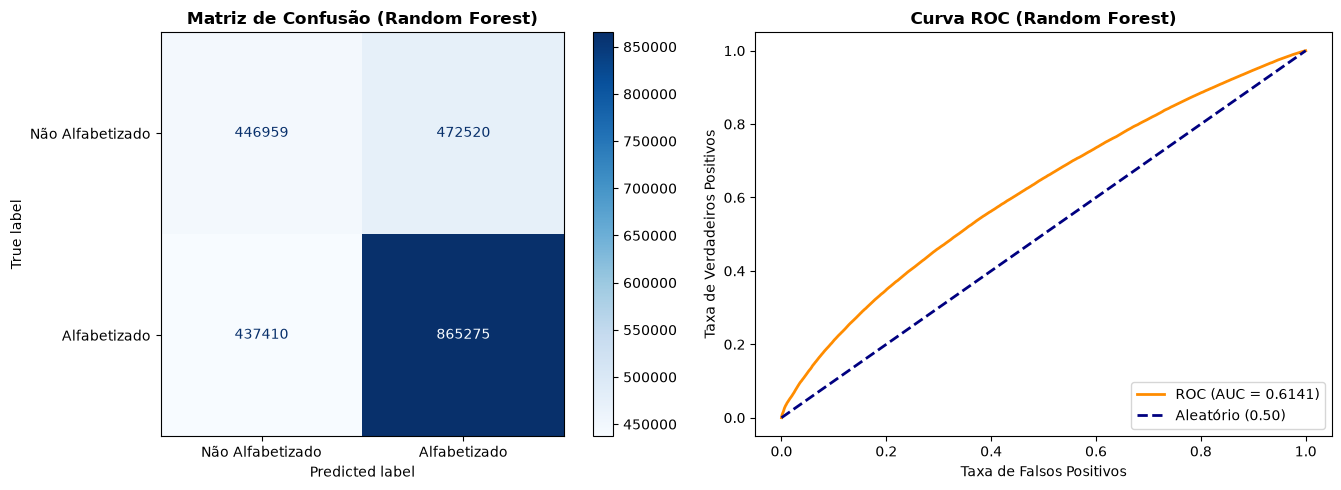

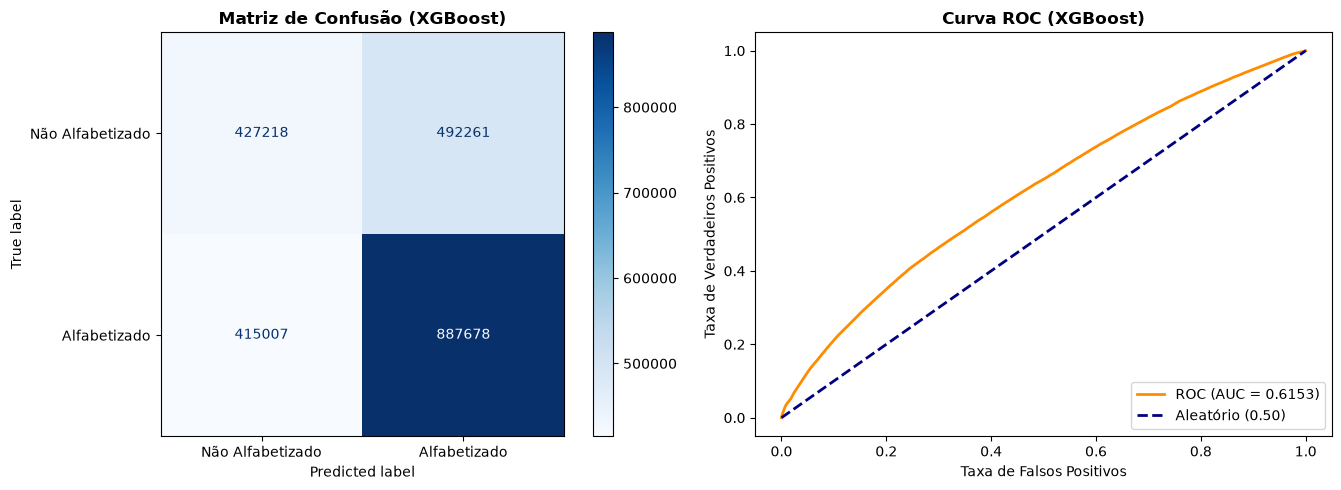

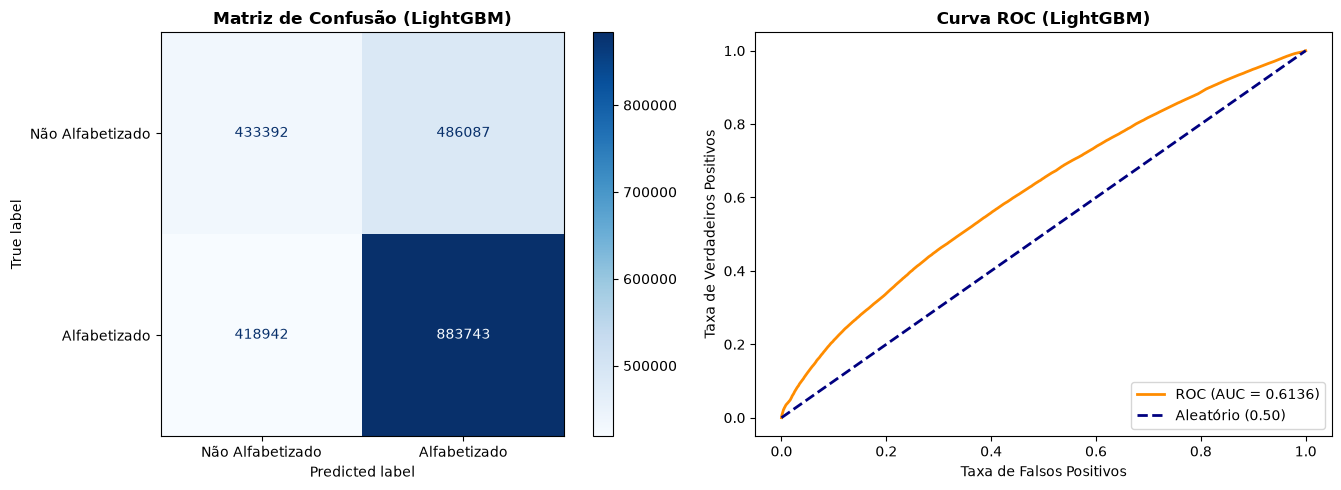

In [68]:
plot_classificacao(rf, X_test, y_test, model_name="Random Forest")

plot_classificacao(xgb, X_test, y_test, model_name="XGBoost")

plot_classificacao(lgbm, X_test, y_test, model_name="LightGBM")

2023
  ↓
histórico
  ↓
2024
  ↓
treinamento + validação interna
  ↓
modelo escolhido
  ↓
2025
  ↓
TESTE FINAL
  ↓
AUC = 0,6186  ← Random Forest

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

importancias_rf = pd.DataFrame({
    "FEATURE": X_train.columns,
    "IMPORTANCIA": rf.feature_importances_
}).sort_values("IMPORTANCIA", ascending=False)

display(importancias_rf)

,FEATURE,IMPORTANCIA
17,taxa_absenteismo_muni_hist,2.601904e-01
15,taxa_absenteismo_escola_hist,1.271895e-01
16,porte_escola_hist,1.256560e-01
18,porte_muni_hist,1.204069e-01
2,RENDIMENTO_MEDIO_MENSAL_REAIS,6.472485e-02
3,RENDA_PERCAPITA_SBENEF_MEDIO,5.654442e-02
9,RENDA_ZSCORE_ANO,5.183425e-02
4,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,5.114548e-02
0,CO_UF,5.027402e-02
8,freq_escolar_norm,4.691334e-02


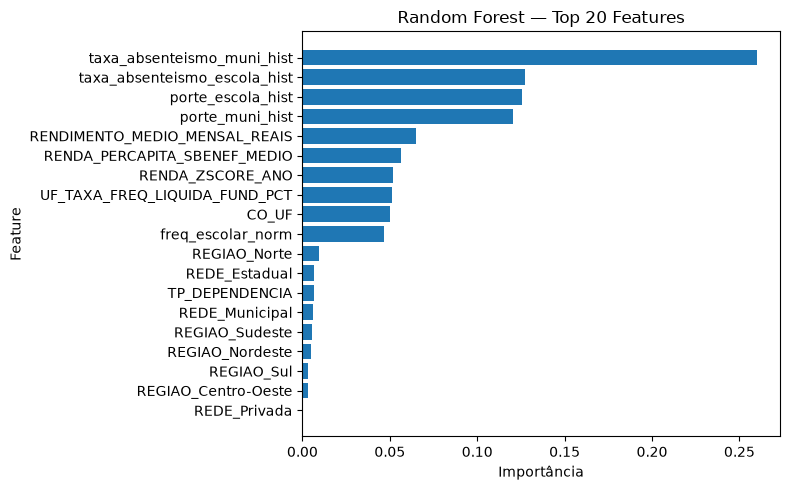

In [70]:
top20_rf = (
    importancias_rf
    .head(20)
    .sort_values("IMPORTANCIA")
)

plt.figure(figsize=(8, 5))
plt.barh(
    top20_rf["FEATURE"],
    top20_rf["IMPORTANCIA"]
)

plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Random Forest — Top 20 Features")
plt.tight_layout()
plt.show()

1. O absenteísmo municipal domina o modelo

taxa_absenteismo_muni_hist tem importância de 0,2602, praticamente o dobro da segunda variável:

Feature	Importância
taxa_absenteismo_muni_hist	26,02%
taxa_absenteismo_escola_hist	12,72%
porte_escola_hist	12,57%
porte_muni_hist	12,04%
rendimento médio	6,47%
renda per capita	5,65%
renda Z-score	5,18%
frequência escolar	5,11%
UF	5,03%

As quatro primeiras juntas representam aproximadamente 63,3% da importância total.

o histórico de frequência/absenteísmo e o porte das estruturas educacionais são os sinais mais utilizados pelo Random Forest.

Mostra que os municípios com histórico de maior absenteísmo aparecem como um importante sinal preditivo de risco de alfabetização.

Atenção: importância não significa causalidade.

### vamos testar o Modelo B com proficiência histórica, mas sem alteração da metodologia.

In [71]:
features_historicas = [
    "TAXA_ALF_MUNICIPIO_HIST",
    "TAXA_ALF_UF_HIST",
    "MEDIA_LP_MUNICIPIO_HIST",
    "MEDIA_LP_UF_HIST",
    "FREQ_UF_HIST"
]

[col for col in features_historicas if col in df_modelo.columns]

[]

In [72]:
# Crie as taxas históricas

# Taxa de alfabetização por município e ano
hist_municipio = (
    df_modelo
    .groupby(["CO_MUNICIPIO", "NU_ANO_AVALIACAO"])["IN_ALFABETIZADO"]
    .mean()
    .reset_index()
    .rename(columns={"IN_ALFABETIZADO": "TAXA_ALF_MUNICIPIO"})
)

hist_municipio = hist_municipio.sort_values(
    ["CO_MUNICIPIO", "NU_ANO_AVALIACAO"]
)

hist_municipio["TAXA_ALF_MUNICIPIO_HIST"] = (
    hist_municipio
    .groupby("CO_MUNICIPIO")["TAXA_ALF_MUNICIPIO"]
    .shift(1)
)

In [73]:
# Taxa de alfabetização por UF e ano
hist_uf = (
    df_modelo
    .groupby(["CO_UF", "NU_ANO_AVALIACAO"])["IN_ALFABETIZADO"]
    .mean()
    .reset_index()
    .rename(columns={"IN_ALFABETIZADO": "TAXA_ALF_UF"})
)

hist_uf = hist_uf.sort_values(
    ["CO_UF", "NU_ANO_AVALIACAO"]
)

hist_uf["TAXA_ALF_UF_HIST"] = (
    hist_uf
    .groupby("CO_UF")["TAXA_ALF_UF"]
    .shift(1)
)

In [74]:
# incorporando as taxas históricas no dataframe principal
df_modelo = df_modelo.merge(
    hist_municipio[
        ["CO_MUNICIPIO", "NU_ANO_AVALIACAO", "TAXA_ALF_MUNICIPIO_HIST"]
    ],
    on=["CO_MUNICIPIO", "NU_ANO_AVALIACAO"],
    how="left"
)

df_modelo = df_modelo.merge(
    hist_uf[
        ["CO_UF", "NU_ANO_AVALIACAO", "TAXA_ALF_UF_HIST"]
    ],
    on=["CO_UF", "NU_ANO_AVALIACAO"],
    how="left"
)

In [75]:
df_modelo.groupby("NU_ANO_AVALIACAO")[
    ["TAXA_ALF_MUNICIPIO_HIST", "TAXA_ALF_UF_HIST"]
].agg(["count", "mean"])

TAXA_ALF_MUNICIPIO_HIST           TAXA_ALF_UF_HIST          
                                   count      mean            count      mean
NU_ANO_AVALIACAO                                                             
2023                                   0       NaN                0       NaN
2024                             1636118  0.503141          1636430  0.503078
2025                             2210585  0.522244          2210816  0.521650

In [76]:
# Acrescentado nas features do modelo
features_rf_prof = features_rf + [
    "TAXA_ALF_MUNICIPIO_HIST",
    "TAXA_ALF_UF_HIST"
]

In [77]:
df_treino = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2024
].copy()

df_teste = df_modelo[
    df_modelo["NU_ANO_AVALIACAO"] == 2025
].copy()

In [78]:
print(
    "TAXA_ALF_MUNICIPIO_HIST" in df_treino.columns,
    "TAXA_ALF_UF_HIST" in df_treino.columns
)

print(
    "TAXA_ALF_MUNICIPIO_HIST" in df_teste.columns,
    "TAXA_ALF_UF_HIST" in df_teste.columns
)

True True
True True


In [79]:
# treino e teste com as novas features
X_train_prof = df_treino[features_rf_prof]
y_train_prof = df_treino[TARGET]

X_test_prof = df_teste[features_rf_prof]
y_test_prof = df_teste[TARGET]

print("Treino:", X_train_prof.shape)
print("Teste:", X_test_prof.shape)

Treino: (2120560, 21)
Teste: (2222164, 21)


In [80]:
print(X_train_prof.shape)
print(X_test_prof.shape)
print(X_train_prof.columns.tolist())

(2120560, 21)
(2222164, 21)
['CO_UF', 'TP_DEPENDENCIA', 'RENDIMENTO_MEDIO_MENSAL_REAIS', 'RENDA_PERCAPITA_SBENEF_MEDIO', 'UF_TAXA_FREQ_LIQUIDA_FUND_PCT', 'REDE_Estadual', 'REDE_Municipal', 'REDE_Privada', 'freq_escolar_norm', 'RENDA_ZSCORE_ANO', 'REGIAO_Centro-Oeste', 'REGIAO_Nordeste', 'REGIAO_Norte', 'REGIAO_Sudeste', 'REGIAO_Sul', 'taxa_absenteismo_escola_hist', 'porte_escola_hist', 'taxa_absenteismo_muni_hist', 'porte_muni_hist', 'TAXA_ALF_MUNICIPIO_HIST', 'TAXA_ALF_UF_HIST']


In [81]:
# Treinar o modelo Random Forest com as novas features
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

modelo_rf_prof = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

modelo_rf_prof.fit(X_train_prof, y_train_prof)

# Probabilidade de alfabetização
prob_rf_prof = modelo_rf_prof.predict_proba(X_test_prof)[:, 1]

# Classe prevista
y_pred_rf_prof = (prob_rf_prof >= 0.5).astype(int)

print("Acurácia:", accuracy_score(y_test_prof, y_pred_rf_prof))
print("Precisão:", precision_score(y_test_prof, y_pred_rf_prof))
print("Recall:", recall_score(y_test_prof, y_pred_rf_prof))
print("F1:", f1_score(y_test_prof, y_pred_rf_prof))
print("AUC-ROC:", roc_auc_score(y_test_prof, prob_rf_prof))

print("\nMatriz de confusão:")
print(confusion_matrix(y_test_prof, y_pred_rf_prof))

print("\nRelatório:")
print(classification_report(y_test_prof, y_pred_rf_prof))

Acurácia: 0.6014470579129173
Precisão: 0.6490186675776172
Recall: 0.6971393698399844
F1: 0.6722189406489225
AUC-ROC: 0.6300671283987865

Matriz de confusão:
[[428361 491118]
 [394532 908153]]

Relatório:
              precision    recall  f1-score   support

           0       0.52      0.47      0.49    919479
           1       0.65      0.70      0.67   1302685

    accuracy                           0.60   2222164
   macro avg       0.58      0.58      0.58   2222164
weighted avg       0.60      0.60      0.60   2222164



| Modelo             |    AUC-ROC |   Acurácia | Recall classe 1 | F1 classe 1 |
| ------------------ | ---------: | ---------: | --------------: | ----------: |
| RF sem histórico   |     0,6186 |     0,5960 |          0,7250 |      0,6778 |
| **RF + histórico** | **0,6301** | **0,6014** |          0,6971 |      0,6722 |


O ganho de AUC de 0,0115 mostra que:

A trajetória histórica de alfabetização do município e da UF acrescenta informação preditiva ao modelo.
AUC-ROC 0,630 ainda é um poder discriminativo moderado. Não é um modelo forte o suficiente para ser tratado como uma previsão individual precisa.

In [82]:
import pandas as pd

importancias = pd.DataFrame({
    "FEATURE": modelo_rf_prof.feature_names_in_,
    "IMPORTANCIA": modelo_rf_prof.feature_importances_
})

importancias = (
    importancias
    .sort_values("IMPORTANCIA", ascending=False)
    .reset_index(drop=True)
)

importancias

,FEATURE,IMPORTANCIA
0,TAXA_ALF_MUNICIPIO_HIST,0.332101
1,TAXA_ALF_UF_HIST,0.178896
2,taxa_absenteismo_muni_hist,0.143693
3,RENDIMENTO_MEDIO_MENSAL_REAIS,0.050838
4,RENDA_ZSCORE_ANO,0.043835
5,UF_TAXA_FREQ_LIQUIDA_FUND_PCT,0.041387
6,freq_escolar_norm,0.039674
7,CO_UF,0.038028
8,porte_muni_hist,0.035786
9,RENDA_PERCAPITA_SBENEF_MEDIO,0.031469


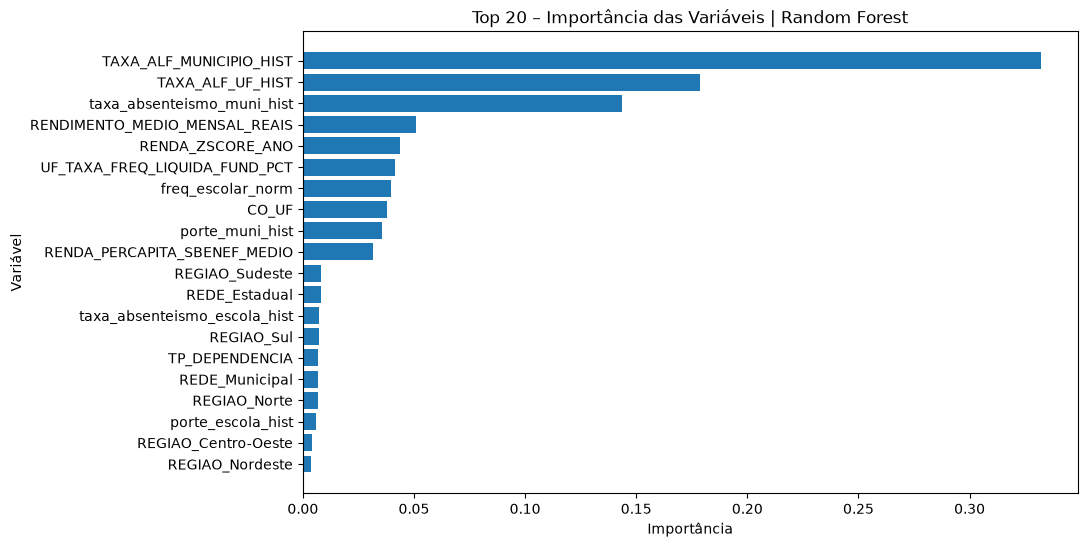

In [83]:
import matplotlib.pyplot as plt

top = importancias.head(20).sort_values("IMPORTANCIA")

plt.figure(figsize=(10, 6))
plt.barh(top["FEATURE"], top["IMPORTANCIA"])
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Top 20 – Importância das Variáveis | Random Forest")
plt.show()

| Posição | Variável                      | Importância |
| ------- | ----------------------------- | ----------: |
| 1       | **TAXA_ALF_MUNICIPIO_HIST**   |  **33,21%** |
| 2       | **TAXA_ALF_UF_HIST**          |  **17,89%** |
| 3       | taxa_absenteismo_muni_hist    |      14,37% |
| 4       | RENDIMENTO_MEDIO_MENSAL_REAIS |       5,08% |
| 5       | RENDA_ZSCORE_ANO              |       4,38% |

As duas variáveis históricas somam: 0,3321 + 0,1789 = 51,1% da importância total.

O histórico recente de alfabetização do município e da UF é o conjunto de variáveis com maior importância para a previsão do status de alfabetização em 2025.
Isso combina com o aumento do AUC:
0,6186 → 0,6301

A taxa histórica de alfabetização apresenta forte associação preditiva com o resultado observado em 2025.

In [84]:
#Precisamos medir o quanto o historico de alfabetização contribui para o modelo, então vamos retirar essas duas variáveis e manter todo o resto igual. 
# TAXA_ALF_MUNICIPIO_HIST, TAXA_ALF_UF_HIST
features_sem_prof = [
    f for f in features_rf_prof
    if f not in [
        "TAXA_ALF_MUNICIPIO_HIST",
        "TAXA_ALF_UF_HIST"
    ]
]

X_train_sem_prof = df_treino[features_sem_prof]
X_test_sem_prof = df_teste[features_sem_prof]

y_train_sem_prof = df_treino[TARGET]
y_test_sem_prof = df_teste[TARGET]

modelo_rf_sem_prof = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

modelo_rf_sem_prof.fit(
    X_train_sem_prof,
    y_train_sem_prof
)

prob_sem_prof = modelo_rf_sem_prof.predict_proba(
    X_test_sem_prof
)[:, 1]

y_pred_sem_prof = (prob_sem_prof >= 0.5).astype(int)

print("Acurácia:", accuracy_score(y_test_sem_prof, y_pred_sem_prof))
print("Precisão:", precision_score(y_test_sem_prof, y_pred_sem_prof))
print("Recall:", recall_score(y_test_sem_prof, y_pred_sem_prof))
print("F1:", f1_score(y_test_sem_prof, y_pred_sem_prof))
print("AUC-ROC:", roc_auc_score(y_test_sem_prof, prob_sem_prof))

Acurácia: 0.5959582641065196
Precisão: 0.6363866062597193
Recall: 0.7250386701313057
F1: 0.6778262556062581
AUC-ROC: 0.6185560153844054


| Modelo             |         AUC |       Acurácia |     Recall |      F1 |
| ------------------ | ----------: | -------------: | ---------: | ------: |
| RF sem histórico   |  **0,6186** |         59,60% |     72,50% |  0,6778 |
| **RF + histórico** |  **0,6301** |     **60,14%** |     69,71% |  0,6722 |
| **Variação**       | **+0,0115** | **+0,54 p.p.** | -2,78 p.p. | -0,0056 |

Vamos manter o RF + histórico como modelo principal, pois a importância das variáveis confirmou que o ganho não é aleatório:

TAXA_ALF_MUNICIPIO_HIST → 33,21%
TAXA_ALF_UF_HIST → 17,89%
Totalizando 51,10% da importância do modelo.


## Previsão de risco por município

In [85]:
# Probabilidade de alfabetização em 2025
df_risco = df_teste.copy()

df_risco["PROB_ALFABETIZADO"] = prob_rf_prof

# Probabilidade de não alfabetização
df_risco["PROB_NAO_ALFABETIZADO"] = (
    1 - df_risco["PROB_ALFABETIZADO"]
)

df_risco[[
    "CO_MUNICIPIO",
    "PROB_ALFABETIZADO",
    "PROB_NAO_ALFABETIZADO"
]].head()

,CO_MUNICIPIO,PROB_ALFABETIZADO,PROB_NAO_ALFABETIZADO
156,1100205.0,0.479181,0.520819
157,1100205.0,0.479181,0.520819
158,1100205.0,0.479181,0.520819
159,1100205.0,0.479181,0.520819
160,1100205.0,0.479181,0.520819


In [86]:
risco_municipio = (
    df_risco
    .groupby("CO_MUNICIPIO")
    .agg(
        ALUNOS=("CO_MUNICIPIO", "size"),
        PROB_ALF_MEDIO=("PROB_ALFABETIZADO", "mean"),
        PROB_NAO_ALF_MEDIO=("PROB_NAO_ALFABETIZADO", "mean")
    )
    .reset_index()
)

risco_municipio["PREVISTA_PCT"] = (
    risco_municipio["PROB_ALF_MEDIO"] * 100
)

risco_municipio["RISCO_PCT"] = (
    risco_municipio["PROB_NAO_ALF_MEDIO"] * 100
)

risco_municipio.head()

,CO_MUNICIPIO,ALUNOS,PROB_ALF_MEDIO,PROB_NAO_ALF_MEDIO,PREVISTA_PCT,RISCO_PCT
0,1100015.0,295,0.614139,0.385861,61.413854,38.586146
1,1100023.0,1891,0.599298,0.400702,59.929781,40.070219
2,1100031.0,64,0.639472,0.360528,63.947152,36.052848
3,1100049.0,1200,0.619966,0.380034,61.996556,38.003444
4,1100056.0,307,0.643610,0.356390,64.360957,35.639043


In [87]:
[x for x in dir() if "meta" in x.lower()]

['cols_metas_mun',
 'cols_metas_uf',
 'df_meta',
 'df_metas_mun_prep',
 'df_metas_uf_prep',
 'gerar_df_resultados_metas',
 'gerar_df_resultados_metas_municipio',
 'renomear_metas_mun',
 'renomear_metas_uf',
 'resultado_metas',
 'resultado_metas_muni']

In [88]:
resultado_metas_muni.columns.tolist()

['NU_ANO_AVALIACAO',
 'CO_UF',
 'SG_UF',
 'CO_MUNICIPIO',
 'NO_MUNICIPIO',
 'NO_TP_REDE',
 'PC_ALUNO_ALFABETIZADO',
 'META_FINAL_2024',
 'META_FINAL_2025',
 'META_FINAL_2026',
 'META_FINAL_2027',
 'META_FINAL_2028',
 'META_FINAL_2029',
 'META_FINAL_2030',
 'NIVEIS_ALFABETIZACAO_2023',
 'PC_AVALIADOS_LP',
 'PC_ALUNO_ALFABETIZADO_2023',
 'PC_ALUNO_ALFABETIZADO_2024',
 'CO_NIVEL_ALFABETIZACAO',
 'PC_ALUNO_ALFABETIZADO_2025']

In [89]:
metas_municipais = (
    resultado_metas_muni[
        ["CO_MUNICIPIO", "NO_MUNICIPIO", "SG_UF", "META_FINAL_2025"]
    ]
    .drop_duplicates("CO_MUNICIPIO")
)

analise_risco = risco_municipio.merge(
    metas_municipais,
    on="CO_MUNICIPIO",
    how="left"
)

analise_risco["DISTANCIA_META"] = (
    analise_risco["PREVISTA_PCT"]
    - analise_risco["META_FINAL_2025"]
)

analise_risco["PREVISTO_ABAIXO_META"] = (
    analise_risco["PREVISTA_PCT"]
    < analise_risco["META_FINAL_2025"]
)

In [90]:
analise_risco[
    [
        "CO_MUNICIPIO",
        "NO_MUNICIPIO",
        "SG_UF",
        "ALUNOS",
        "PREVISTA_PCT",
        "META_FINAL_2025",
        "DISTANCIA_META",
        "PREVISTO_ABAIXO_META"
    ]
].sort_values("DISTANCIA_META").head(20)

,CO_MUNICIPIO,NO_MUNICIPIO,SG_UF,ALUNOS,PREVISTA_PCT,META_FINAL_2025,DISTANCIA_META,PREVISTO_ABAIXO_META
4808,4310553.0,Itacurubi,RS,17,33.392724,80.000000,-46.607276,True
4761,4308052.0,Faxinalzinho,RS,23,33.587185,78.711901,-45.124715,True
4917,4314779.0,Pontão,RS,31,33.422203,78.257154,-44.834951,True
4713,4305850.0,Coqueiros do Sul,RS,18,35.176553,80.000000,-44.823447,True
4692,4304952.0,Caseiros,RS,46,35.265159,80.000000,-44.734841,True
5053,4321956.0,Trindade do Sul,RS,76,36.228471,80.000000,-43.771529,True
4842,4312005.0,Mariano Moro,RS,13,36.489942,80.000000,-43.510058,True
4618,4300877.0,Araricá,RS,160,33.771373,76.982796,-43.211422,True
5060,4322301.0,Tuparendi,RS,62,36.803742,80.000000,-43.196258,True
4984,4318465.0,São José do Herval,RS,23,36.975043,80.000000,-43.024957,True


Há municípios com pouquissimos alunos, o que torna a estimativa muito instável. Não necessiarimante são nosso maior Risco.
Precisamos separar: distância da meta × tamanho da população analisada.

In [91]:
#filtrando os municípios com mais de 100 alunos e que estão abaixo da meta, ordenando pelo maior risco (distância da meta)
risco_priorizado = (
    analise_risco[
        (analise_risco["ALUNOS"] >= 100) &
        (analise_risco["PREVISTO_ABAIXO_META"])
    ]
    .sort_values("DISTANCIA_META")
)

risco_priorizado[
    [
        "CO_MUNICIPIO",
        "NO_MUNICIPIO",
        "SG_UF",
        "ALUNOS",
        "PREVISTA_PCT",
        "META_FINAL_2025",
        "DISTANCIA_META"
    ]
].head(20)

,CO_MUNICIPIO,NO_MUNICIPIO,SG_UF,ALUNOS,PREVISTA_PCT,META_FINAL_2025,DISTANCIA_META
4618,4300877.0,Araricá,RS,160,33.771373,76.982796,-43.211422
4676,4304408.0,Canela,RS,570,36.446999,79.063511,-42.616512
4992,4318804.0,São Lourenço do Sul,RS,426,37.652568,79.353070,-41.700502
4712,4305801.0,Constantina,RS,126,38.458926,80.000000,-41.541074
5019,4320404.0,Serafina Corrêa,RS,176,39.092264,80.000000,-40.907736
4800,4310330.0,Imbé,RS,351,29.864866,70.524767,-40.659902
4550,4216305.0,São João Batista,SC,470,35.832312,76.468218,-40.635907
4582,4218707.0,Tubarão,SC,1181,33.036838,73.345335,-40.308496
4641,4302105.0,Bento Gonçalves,RS,1240,38.415188,78.152571,-39.737383
4994,4319000.0,São Marcos,RS,198,40.282083,80.000000,-39.717917


PREVISTA_PCT não é necessariamente a taxa real prevista de alfabetização do município. Ela é a média das probabilidades individuais produzidas pelo modelo.

Priorizaçãofinal dos municípios:

tamanho da população de alunos X
previsão de alfabetização X
distância da meta.

In [92]:
# 1. Estimativa de alunos não alfabetizados
analise_risco["ALUNOS_NAO_ALF_EST"] = (
    analise_risco["ALUNOS"]
    * (1 - analise_risco["PREVISTA_PCT"] / 100)
)

# 2. Déficit em relação à meta
analise_risco["DEFICIT_META_PCT"] = (
    analise_risco["META_FINAL_2025"]
    - analise_risco["PREVISTA_PCT"]
)

# 3. Municípios com pelo menos 100 alunos e abaixo da meta
priorizacao = (
    analise_risco[
        (analise_risco["ALUNOS"] >= 100) &
        (analise_risco["PREVISTO_ABAIXO_META"])
    ]
    .sort_values("ALUNOS_NAO_ALF_EST", ascending=False)
)

# 4. Top 20
priorizacao[
    [
        "NO_MUNICIPIO",
        "SG_UF",
        "ALUNOS",
        "PREVISTA_PCT",
        "META_FINAL_2025",
        "DEFICIT_META_PCT",
        "ALUNOS_NAO_ALF_EST"
    ]
].head(20)

,NO_MUNICIPIO,SG_UF,ALUNOS,PREVISTA_PCT,META_FINAL_2025,DEFICIT_META_PCT,ALUNOS_NAO_ALF_EST
3239,Rio de Janeiro,RJ,49539,54.637438,63.965180,9.327742,22472.159450
111,Manaus,AM,29558,39.216148,61.277262,22.061114,17966.491045
2162,Salvador,BA,14955,32.700993,52.033273,19.332280,10064.566560
3476,Guarulhos,SP,16316,46.770117,52.227564,5.457447,8684.987666
4001,Curitiba,PR,15636,54.417052,73.405561,18.988509,7127.349778
4920,Porto Alegre,RS,9664,26.264312,52.688815,26.424503,7125.816920
2309,Belo Horizonte,MG,19588,64.597725,64.912956,0.315231,6934.597555
169,Belém,PA,10632,42.941374,58.545443,15.604070,6066.473136
3196,Duque de Caxias,RJ,8458,36.124550,57.799966,21.675416,5402.585558
5107,Campo Grande,MS,11254,53.470387,53.844426,0.374039,5236.442616


Temos dois tipos de prioridade:

🔴 Alta prioridade por déficit

Porto Alegre
Manaus
Duque de Caxias
Joinville
Natal

São municípios em que a distância para a meta é muito grande.

🟠 Alta prioridade por volume

Rio de Janeiro
Manaus
Salvador
Guarulhos
Curitiba

Aqui o problema é o número absoluto de alunos potencialmente afetados.

Em Belo Horizonte o modelo prevê 64,6%, praticamente a meta de 64,9%. Mesmo assim, aparecem aproximadamente 6.935 alunos não alfabetizados.

**O modelo permite combinar risco e escala, identificando não apenas municípios distantes das metas, mas também aqueles onde o número potencial de alunos não alfabetizados é maior. Essa abordagem ajuda a direcionar políticas públicas de forma mais estratégica.**

In [93]:
# Análise do histórico de alfabetização por município
analise_historico = analise_risco[
    [
        "CO_MUNICIPIO",
        "NO_MUNICIPIO",
        "SG_UF",
        "ALUNOS",
        "PREVISTA_PCT",
        "META_FINAL_2025"
    ]
].copy()

# Histórico disponível no conjunto de teste de 2025
hist_2025 = (
    df_teste[
        ["CO_MUNICIPIO", "TAXA_ALF_MUNICIPIO_HIST"]
    ]
    .drop_duplicates("CO_MUNICIPIO")
)

analise_historico = analise_historico.merge(
    hist_2025,
    on="CO_MUNICIPIO",
    how="left"
)

analise_historico["VARIACAO_PREV_HIST"] = (
    analise_historico["PREVISTA_PCT"]
    - analise_historico["TAXA_ALF_MUNICIPIO_HIST"] * 100
)

In [94]:
analise_historico[
    analise_historico["ALUNOS"] >= 100
].sort_values(
    "VARIACAO_PREV_HIST"
).head(20)

,CO_MUNICIPIO,NO_MUNICIPIO,SG_UF,ALUNOS,PREVISTA_PCT,META_FINAL_2025,TAXA_ALF_MUNICIPIO_HIST,VARIACAO_PREV_HIST
3849,3552601.0,Tabapuã,SP,110,65.135011,80.000000,0.943820,-29.247012
3680,3537107.0,Pedreira,SP,395,64.468741,80.000000,0.919240,-27.455249
3661,3535408.0,Panorama,SP,161,64.526308,80.000000,0.902857,-25.759407
3880,3555109.0,Tupi Paulista,SP,122,63.876045,80.000000,0.883721,-24.496048
5194,5102793.0,Carlinda,MT,151,72.086978,54.506580,0.960000,-23.913022
3419,3514007.0,<NA>,<NA>,101,65.417349,NaN,0.886598,-23.242444
1507,2603926.0,Carnaubeira da Penha,PE,101,76.793122,80.000000,1.000000,-23.206878
1318,2505709.0,Dona Inês,PB,139,58.178755,59.002742,0.808511,-22.672309
3865,3553955.0,Tarumã,SP,192,62.981223,80.000000,0.854369,-22.455671
105,1302108.0,Japurá,AM,165,53.530911,78.096848,0.747826,-21.251698


Há municípios em que a taxa histórica de alfabetização é extremamente alta:

Tabapuã: 94,4%
Pedreira: 91,9%
Panorama: 90,3%
Carlinda: 96,0%
Carnaubeira da Penha: 100%

Mas o modelo prevê taxas bem menores para 2025.

Isso pode acontecer, mas é um sinal que precisamos investigar, porque nosso modelo tem AUC apenas 0,63 e está usando muitas variáveis contextuais.

In [95]:
# Correlação entre a taxa histórica de alfabetização e a previsão do modelo
analise_historico[
    [
        "TAXA_ALF_MUNICIPIO_HIST",
        "PREVISTA_PCT"
    ]
].corr()

,TAXA_ALF_MUNICIPIO_HIST,PREVISTA_PCT
TAXA_ALF_MUNICIPIO_HIST,1.000000,0.888628
PREVISTA_PCT,0.888628,1.000000


Confirmando o obvio. Municípios que apresentaram melhores resultados históricos tendem a receber maiores probabilidades de alfabetização em 2025 pelo modelo.
O histórico municipal é o principal sinal preditivo, mas o modelo combina essa trajetória com fatores socioeconômicos, educacionais e territoriais para gerar a previsão de 2025.

In [96]:
# Municípios com taxa histórica de alfabetização acima de 80% e mais de 100 alunos
analise_historico[
    (analise_historico["TAXA_ALF_MUNICIPIO_HIST"] >= 0.80) &
    (analise_historico["ALUNOS"] >= 100)
][
    [
        "NO_MUNICIPIO",
        "SG_UF",
        "ALUNOS",
        "TAXA_ALF_MUNICIPIO_HIST",
        "PREVISTA_PCT",
        "META_FINAL_2025",
        "VARIACAO_PREV_HIST"
    ]
].sort_values(
    "TAXA_ALF_MUNICIPIO_HIST",
    ascending=False
).head(20)

,NO_MUNICIPIO,SG_UF,ALUNOS,TAXA_ALF_MUNICIPIO_HIST,PREVISTA_PCT,META_FINAL_2025,VARIACAO_PREV_HIST
1507,Carnaubeira da Penha,PE,101,1.000000,76.793122,80.0,-23.206878
1033,Pires Ferreira,CE,120,1.000000,93.647723,80.0,-6.352277
1032,Piquet Carneiro,CE,154,1.000000,94.391300,80.0,-5.608700
1020,Pacujá,CE,133,1.000000,94.481200,80.0,-5.518800
939,Coreaú,CE,257,1.000000,93.733576,80.0,-6.266424
1027,Pedra Branca,CE,432,0.997015,93.724992,80.0,-5.976500
1014,Novo Oriente,CE,368,0.997015,93.341240,80.0,-6.360252
948,Forquilha,CE,264,0.995652,94.293922,80.0,-5.271295
972,Ipueiras,CE,458,0.995381,93.731644,80.0,-5.806462
1012,Nova Olinda,CE,212,0.995305,93.699570,80.0,-5.830947


Nos municípios do Ceará, por exemplo, o histórico é muito alto e o modelo mantém uma previsão também alta:

Piquet Carneiro: histórico 100% → previsão 94,4%
Pacujá: 100% → 94,5%
Coreaú: 100% → 93,7%
Forquilha: 99,6% → 94,3%
Ipueiras: 99,5% → 93,7%

Isso é coerente com a correlação de 0,8886 que encontramos.

Mas temos um caso que merece atenção

Carnaubeira da Penha (PE):

Histórico: 100%
Previsão: 76,8%
Meta: 80%
Déficit previsto: -3,2 p.p.

Ou seja, o modelo está dizendo:

Apesar do excelente resultado histórico, existem outros fatores no perfil desse município que fazem a previsão de 2025 ficar abaixo da meta.

Isso é justamente uma das vantagens de combinar histórico com outras variáveis.

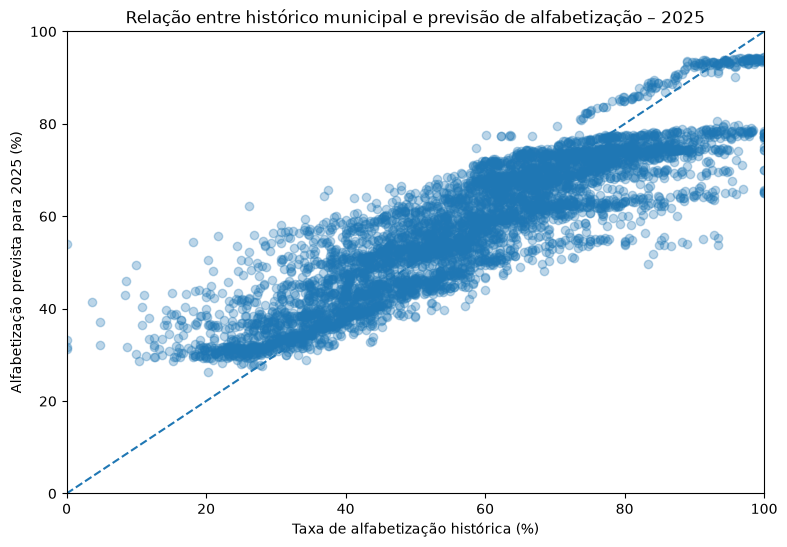

In [97]:
# Visualização da relação entre histórico de alfabetização e previsão do modelo
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    analise_historico["TAXA_ALF_MUNICIPIO_HIST"] * 100,
    analise_historico["PREVISTA_PCT"],
    alpha=0.3
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Taxa de alfabetização histórica (%)")
plt.ylabel("Alfabetização prevista para 2025 (%)")
plt.title(
    "Relação entre histórico municipal e previsão de alfabetização – 2025"
)

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.show()

Há uma espécie de "compressão" das previsões:

municípios com histórico muito baixo → previsões tendem a ficar um pouco acima;
municípios com histórico muito alto → previsões tendem a ficar abaixo do histórico.

Isso é compatível com um modelo que busca generalizar e combinar o histórico com outros fatores, mas também indica que o modelo não está reproduzindo perfeitamente as diferenças extremas entre municípios.
A forte associação entre o desempenho histórico municipal e a previsão para 2025 demonstra que o modelo captura a persistência do desempenho educacional, mas incorpora também outros fatores para ajustar a previsão

In [98]:
# calibrar o modelo Random Forest com as novas features e histórico de alfabetização de 2024
from sklearn.model_selection import train_test_split

X_tr_cal, X_val_cal, y_tr_cal, y_val_cal = train_test_split(
    X_train_prof,
    y_train_prof,
    test_size=0.20,
    random_state=42,
    stratify=y_train_prof
)

# treinar o modelo Random Forest com os hiperparâmetros encontrados anteriormente
modelo_rf_cal = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

modelo_rf_cal.fit(X_tr_cal, y_tr_cal)

prob_val = modelo_rf_cal.predict_proba(X_val_cal)[:, 1]

In [99]:
# Calibrar o modelo usando Isotonic Regression - para ajustar a relação entre probabilidade prevista e frequência observada
from sklearn.isotonic import IsotonicRegression

calibrador = IsotonicRegression(
    y_min=0,
    y_max=1,
    out_of_bounds="clip"
)

calibrador.fit(prob_val, y_val_cal)

,"y_min y_min: float, default=NoneLower bound on the lowest predicted value (the minimum value maystill be higher). If not set, defaults to -inf.",0
,"y_max y_max: float, default=NoneUpper bound on the highest predicted value (the maximum may still belower). If not set, defaults to +inf.",1
,"out_of_bounds out_of_bounds: {'nan', 'clip', 'raise'}, default='nan'Handles how `X` values outside of the training domain are handledduring prediction.- 'nan', predictions will be NaN.- 'clip', predictions will be set to the value corresponding to the nearest train interval endpoint.- 'raise', a `ValueError` is raised.",'clip'
,"increasing increasing: bool or 'auto', default=TrueDetermines whether the predictions should be constrained to increaseor decrease with `X`. 'auto' will decide based on the Spearmancorrelation estimate's sign.",True
Name,Type,Value
X_max_ X_max_: floatMaximum value of input array `X_` for right bound.,float64,0.9384
X_min_ X_min_: floatMinimum value of input array `X_` for left bound.,float64,0.1573
"X_thresholds_ X_thresholds_: ndarray of shape (n_thresholds,)Unique ascending `X` values used to interpolatethe y = f(X) monotonic function... versionadded:: 0.24","ndarray[float64](201,)","[0.16,0.2 ,0.21,...,0.94,0.94,0.94]"
f_ f_: functionThe stepwise interpolating function that covers the input domain ``X``.,interp1d,<scipy.interp...t 0x162a9b490>
increasing_ increasing_: boolInferred value for ``increasing``.,bool,True
"y_thresholds_ y_thresholds_: ndarray of shape (n_thresholds,)De-duplicated `y` values suitable to interpolate the y = f(X)monotonic function... versionadded:: 0.24","ndarray[float64](201,)","[0. ,0. ,0.04,...,0.98,1. ,1. ]"


In [100]:
# validar o modelo calibrado em 2025
prob_2025 = modelo_rf_cal.predict_proba(X_test_prof)[:, 1]

prob_2025_calibrada = calibrador.predict(prob_2025)

In [101]:
# comparação das métricas de Brier antes e depois da calibração
from sklearn.metrics import brier_score_loss

print(
    "Brier antes:",
    brier_score_loss(y_test_prof, prob_2025)
)

print(
    "Brier depois:",
    brier_score_loss(y_test_prof, prob_2025_calibrada)
)

Brier antes: 0.233463345668937
Brier depois: 0.2340177276931295


Quanto menor o Brier Score, melhor a calibração. Como houve uma pequena piora: +0,00055

**É uma diferença pequena, mas suficiente para decidirmos que não vale a pena usar essa calibração no modelo final neste momento.**


In [102]:
# A - Lista dos municípios com maior déficit em relação à meta de alfabetização
top_deficit = (
    analise_risco[
        (analise_risco["ALUNOS"] >= 100) &
        (analise_risco["PREVISTO_ABAIXO_META"])
    ]
    .sort_values("DEFICIT_META_PCT", ascending=False)
)

top_deficit[
    [
        "NO_MUNICIPIO",
        "SG_UF",
        "ALUNOS",
        "PREVISTA_PCT",
        "META_FINAL_2025",
        "DEFICIT_META_PCT"
    ]
].head(20)

,NO_MUNICIPIO,SG_UF,ALUNOS,PREVISTA_PCT,META_FINAL_2025,DEFICIT_META_PCT
4618,Araricá,RS,160,33.771373,76.982796,43.211422
4676,Canela,RS,570,36.446999,79.063511,42.616512
4992,São Lourenço do Sul,RS,426,37.652568,79.353070,41.700502
4712,Constantina,RS,126,38.458926,80.000000,41.541074
5019,Serafina Corrêa,RS,176,39.092264,80.000000,40.907736
4800,Imbé,RS,351,29.864866,70.524767,40.659902
4550,São João Batista,SC,470,35.832312,76.468218,40.635907
4582,Tubarão,SC,1181,33.036838,73.345335,40.308496
4641,Bento Gonçalves,RS,1240,38.415188,78.152571,39.737383
4994,São Marcos,RS,198,40.282083,80.000000,39.717917


In [103]:
# B - Lista dos municípios com maior número de alunos não alfabetizados estimados
top_impacto = (
    analise_risco[
        (analise_risco["ALUNOS"] >= 100) &
        (analise_risco["PREVISTO_ABAIXO_META"])
    ]
    .sort_values("ALUNOS_NAO_ALF_EST", ascending=False)
)

top_impacto[
    [
        "NO_MUNICIPIO",
        "SG_UF",
        "ALUNOS",
        "PREVISTA_PCT",
        "META_FINAL_2025",
        "DEFICIT_META_PCT",
        "ALUNOS_NAO_ALF_EST"
    ]
].head(20)

,NO_MUNICIPIO,SG_UF,ALUNOS,PREVISTA_PCT,META_FINAL_2025,DEFICIT_META_PCT,ALUNOS_NAO_ALF_EST
3239,Rio de Janeiro,RJ,49539,54.637438,63.965180,9.327742,22472.159450
111,Manaus,AM,29558,39.216148,61.277262,22.061114,17966.491045
2162,Salvador,BA,14955,32.700993,52.033273,19.332280,10064.566560
3476,Guarulhos,SP,16316,46.770117,52.227564,5.457447,8684.987666
4001,Curitiba,PR,15636,54.417052,73.405561,18.988509,7127.349778
4920,Porto Alegre,RS,9664,26.264312,52.688815,26.424503,7125.816920
2309,Belo Horizonte,MG,19588,64.597725,64.912956,0.315231,6934.597555
169,Belém,PA,10632,42.941374,58.545443,15.604070,6066.473136
3196,Duque de Caxias,RJ,8458,36.124550,57.799966,21.675416,5402.585558
5107,Campo Grande,MS,11254,53.470387,53.844426,0.374039,5236.442616


🔴 Municípios com maior déficit percentual
→ onde a distância da meta é mais preocupante.

🟠 Municípios com maior impacto potencial
→ onde uma intervenção pode alcançar maior número de alunos.

O modelo permite identificar tanto municípios com maior distância das metas quanto aqueles que concentram o maior número estimado de alunos não alfabetizados, apoiando a priorização de políticas públicas. 

A análise identifica dois tipos de prioridade: municípios com maior distância em relação à meta e municípios que concentram o maior número estimado de alunos não alfabetizados. Essa distinção evita tratar todos os territórios da mesma forma e permite direcionar estratégias de intervenção conforme a escala e a intensidade do problema 

Modelo: Random Forest + histórico
AUC: 0,6301
Histórico municipal + UF: 51,1% da importância
Correlação histórico × previsão: 0,8886
Aplicação: previsão 2025 × metas municipais
Priorização: déficit × impacto potencial

Só faço uma ressalva para o relatório: ALUNOS_NAO_ALF_EST é uma estimativa baseada nas probabilidades do modelo, não uma contagem observada de alunos não alfabetizados.

### <font color="green"> Salvando Modelo </font>

In [ ]:
import joblib
import os

# Garante que a pasta models existe
os.makedirs("models", exist_ok=True)

# Salva o modelo treinado
caminho_local = "models/melhor_modelo_random_forest_com_historico.joblib"
joblib.dump(rf, caminho_local)

tamanho_mb = os.path.getsize(caminho_local) / (1024 * 1024)
print(f"Modelo Random Forest salvo com sucesso em: {caminho_local} ({tamanho_mb:.2f} MB)")

#SALVAR NO S3 
caminho_s3 = "models/melhor_modelo_random_forest_com_historico.joblib"

# Faz o upload do arquivo salvo para o bucket
s3.upload_file(caminho_local, BUCKET, caminho_s3)
print(f"Modelo enviado com sucesso para s3://{BUCKET}/{caminho_s3}!")

Modelo Random Forest salvo com sucesso em: models/melhor_modelo_random_forest_com_historico.joblib (410.93 MB)
 Modelo enviado com sucesso para s3://postech-challenge-datascience-003/models/melhor_modelo_random_forest_com_historico.joblib!


### <font color="green"> Avaliação </font>

In [ ]:
#import joblib
# Carrega o modelo treinado instantaneamente (sem precisar treinar de novo)
#modelo_carregado = joblib.load("models/melhor_modelo_random_forest_com_historico.joblib")

#  # Faz previsões com ele:
# novas_previsoes = modelo_carregado.predict(X_test)
# print("Previsões geradas com sucesso!")

In [104]:
# ============================================================
# CENÁRIO FUTURO: redução de 20% no absenteísmo histórico
# ============================================================

X_futuro = X_test_prof.copy()

# Redução simulada de 20%
X_futuro["taxa_absenteismo_escola_hist"] *= 0.80
X_futuro["taxa_absenteismo_muni_hist"] *= 0.80

# Previsões no cenário atual
prob_atual = modelo_rf_prof.predict_proba(X_test_prof)[:, 1]

# Previsões no cenário futuro
prob_futuro = modelo_rf_prof.predict_proba(X_futuro)[:, 1]

# Taxas médias
taxa_atual_modelo = prob_atual.mean() * 100
taxa_futura_modelo = prob_futuro.mean() * 100

ganho = taxa_futura_modelo - taxa_atual_modelo

print(f"Taxa prevista atual       : {taxa_atual_modelo:.2f}%")
print(f"Taxa prevista no cenário : {taxa_futura_modelo:.2f}%")
print(f"Ganho estimado            : {ganho:+.2f} p.p.")

Taxa prevista atual       : 53.68%
Taxa prevista no cenário : 54.65%
Ganho estimado            : +0.98 p.p.


No cenário simulado de redução de 20% no absenteísmo, o modelo estima um aumento de aproximadamente 0,98 ponto percentual na taxa de alfabetização, passando de 53,68% para 54,65%.
O ganho não é enorme, mas mostra que o absenteísmo tem sinal preditivo, sem ser o único fator determinante. Isso combina com a importância que encontramos para as variáveis históricas de alfabetização e absenteísmo.

In [105]:
# análise de sensibilidade do absenteísmo.
# Cenários de redução do absenteísmo
reducoes = [0, 0.10, 0.20, 0.30, 0.40]

resultados_cenarios = []

for reducao in reducoes:

    X_cenario = X_test_prof.copy()

    X_cenario["taxa_absenteismo_escola_hist"] *= (1 - reducao)
    X_cenario["taxa_absenteismo_muni_hist"] *= (1 - reducao)

    prob = modelo_rf_prof.predict_proba(X_cenario)[:, 1]

    taxa_prevista = prob.mean() * 100

    resultados_cenarios.append({
        "REDUCAO_ABSENTEISMO": reducao * 100,
        "TAXA_PREVISTA": taxa_prevista
    })

df_cenarios = pd.DataFrame(resultados_cenarios)

# Ganho em relação ao cenário atual
taxa_base = df_cenarios.loc[
    df_cenarios["REDUCAO_ABSENTEISMO"] == 0,
    "TAXA_PREVISTA"
].iloc[0]

df_cenarios["GANHO_P_P"] = (
    df_cenarios["TAXA_PREVISTA"] - taxa_base
)

df_cenarios

,REDUCAO_ABSENTEISMO,TAXA_PREVISTA,GANHO_P_P
0,0.0,53.675093,0.000000
1,10.0,54.115323,0.440230
2,20.0,54.653329,0.978235
3,30.0,55.096646,1.421553
4,40.0,55.591311,1.916217


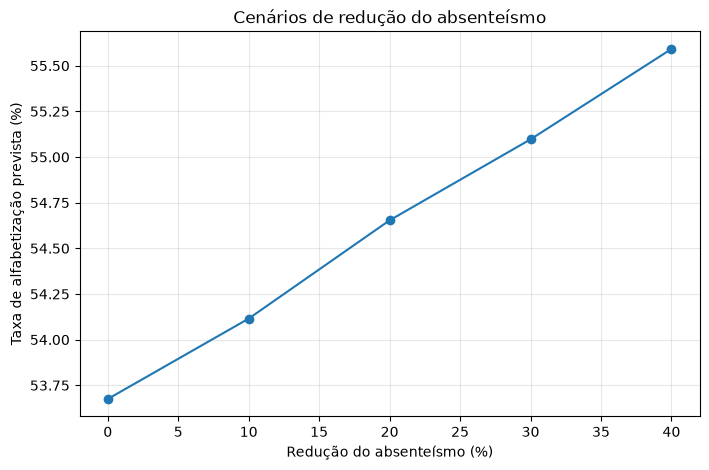

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    df_cenarios["REDUCAO_ABSENTEISMO"],
    df_cenarios["TAXA_PREVISTA"],
    marker="o"
)

plt.xlabel("Redução do absenteísmo (%)")
plt.ylabel("Taxa de alfabetização prevista (%)")
plt.title("Cenários de redução do absenteísmo")
plt.grid(alpha=0.3)

plt.show()

A simulação de cenários indica que a redução do absenteísmo pode contribuir para a melhoria da alfabetização. No cenário de redução de 40%, a taxa prevista passa de 53,68% para 55,59%, um ganho estimado de 1,92 p.p.
Resultado de simulação contrafactual do modelo; não representa estimativa de efeito causal.

In [107]:
# Pega os dados consolidados do Brasil 

brasil = resultado_metas[resultado_metas["SIGLA_UF"].isna()].iloc[0]

anos_historico  = [2019, 2021, 2023]
taxas_historico = [float(brasil["SAEB_2019"]), float(brasil["SAEB_2021"]), float(brasil["PC_ALUNO_ALFABETIZADO"])]

print("Anos Históricos:", anos_historico)
print("Taxas Históricas (%):", taxas_historico)


Anos Históricos: [2019, 2021, 2023]
Taxas Históricas (%): [54.7, 35.77, 55.89811007513037]


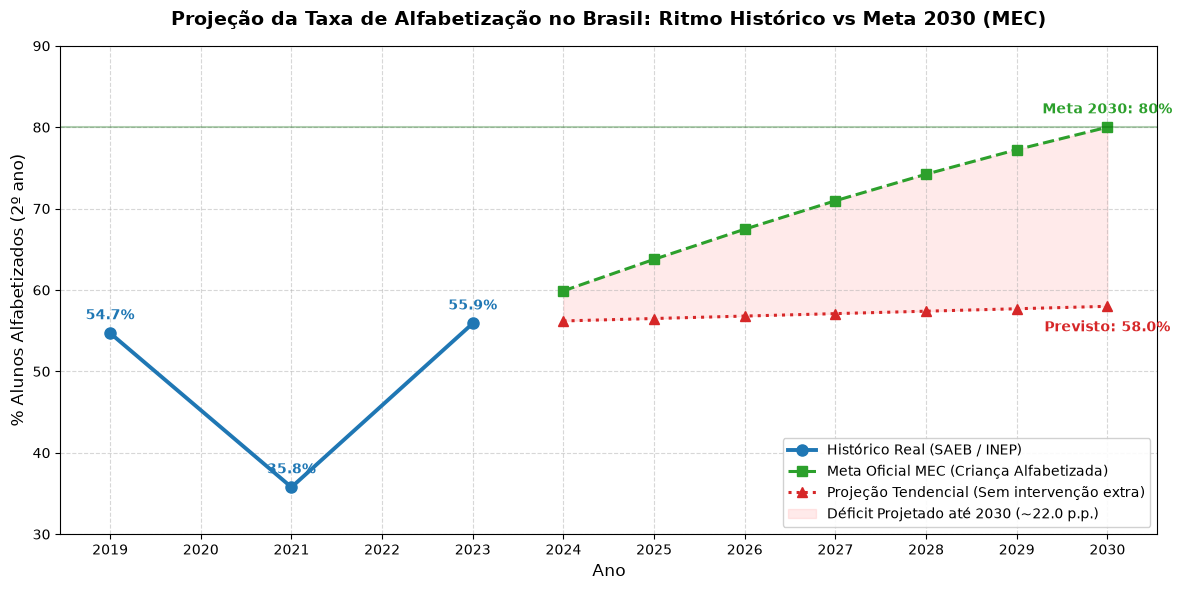

Conclusão da Projeção:
Taxa observada em 2023: 55.90%
Projeção inercial para 2030: 57.99%
Meta oficial do MEC para 2030: 80.00%
Gap a ser superado: 22.01 pontos percentuais


In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Extração dos Dados Oficiais (Brasil) 
linha_brasil = resultado_metas[resultado_metas["NOME_UF"] == "Brasil"].iloc[0]

# Histórico Real Observado no SAEB (2019 a 2023)
anos_hist = np.array([2019, 2021, 2023]).reshape(-1, 1)
taxas_hist = np.array([
    linha_brasil["SAEB_2019"],
    linha_brasil["SAEB_2021"],
    linha_brasil["PC_ALUNO_ALFABETIZADO"]
])

# Metas Oficiais do MEC (2024 a 2030)
anos_futuros = np.array([2024, 2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
metas_mec = np.array([
    linha_brasil["META_FINAL_2024"],
    linha_brasil["META_FINAL_2025"],
    linha_brasil["META_FINAL_2026"],
    linha_brasil["META_FINAL_2027"],
    linha_brasil["META_FINAL_2028"],
    linha_brasil["META_FINAL_2029"],
    80.0  # Meta 2030 fixada em 80%
])

# Modelo de Projeção de Tendência Inercial 
# Usamos a taxa pré-pandemia (2019) e retomada (2023) para projetar o ritmo estrutural
anos_base = np.array([2019, 2023]).reshape(-1, 1)
taxas_base = np.array([taxas_hist[0], taxas_hist[2]])

reg_tendencia = LinearRegression().fit(anos_base, taxas_base)
projecao_tendencia = reg_tendencia.predict(anos_futuros)

# Gráfico Executivo: Histórico vs Projeção vs Meta 2030 
plt.figure(figsize=(12, 6))

# Linha 1: Histórico Real SAEB
plt.plot(anos_hist.flatten(), taxas_hist, marker='o', color='#1f77b4', lw=2.8, markersize=8, label="Histórico Real (SAEB / INEP)")
for x, y in zip(anos_hist.flatten(), taxas_hist):
    plt.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', color='#1f77b4')

# Linha 2: Metas do MEC até 2030
plt.plot(anos_futuros.flatten(), metas_mec, marker='s', color='#2ca02c', linestyle='--', lw=2.2, markersize=7, label="Meta Oficial MEC (Criança Alfabetizada)")
plt.annotate(f"Meta 2030: {metas_mec[-1]:.0f}%", (2030, metas_mec[-1]), textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', color='#2ca02c')

# Linha 3: Projeção de Tendência Inercial
plt.plot(anos_futuros.flatten(), projecao_tendencia, marker='^', color='#d62728', linestyle=':', lw=2.2, markersize=7, label="Projeção Tendencial (Sem intervenção extra)")
plt.annotate(f"Previsto: {projecao_tendencia[-1]:.1f}%", (2030, projecao_tendencia[-1]), textcoords="offset points", xytext=(0, -18), ha='center', fontweight='bold', color='#d62728')

# Linha horizontal de corte da Meta de 80%
plt.axhline(80, color='darkgreen', linestyle='-', alpha=0.3, lw=1.5)

# Destaque do Gap em 2030
gap_2030 = metas_mec[-1] - projecao_tendencia[-1]
plt.fill_between(anos_futuros.flatten(), projecao_tendencia, metas_mec, color='#ff9999', alpha=0.2, label=f"Déficit Projetado até 2030 (~{gap_2030:.1f} p.p.)")

plt.title("Projeção da Taxa de Alfabetização no Brasil: Ritmo Histórico vs Meta 2030 (MEC)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("% Alunos Alfabetizados (2º ano)", fontsize=12)
plt.xticks(np.arange(2019, 2031, 1))
plt.ylim(30, 90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"Conclusão da Projeção:")
print(f"Taxa observada em 2023: {taxas_hist[-1]:.2f}%")
print(f"Projeção inercial para 2030: {projecao_tendencia[-1]:.2f}%")
print(f"Meta oficial do MEC para 2030: 80.00%")
print(f"Gap a ser superado: {gap_2030:.2f} pontos percentuais")


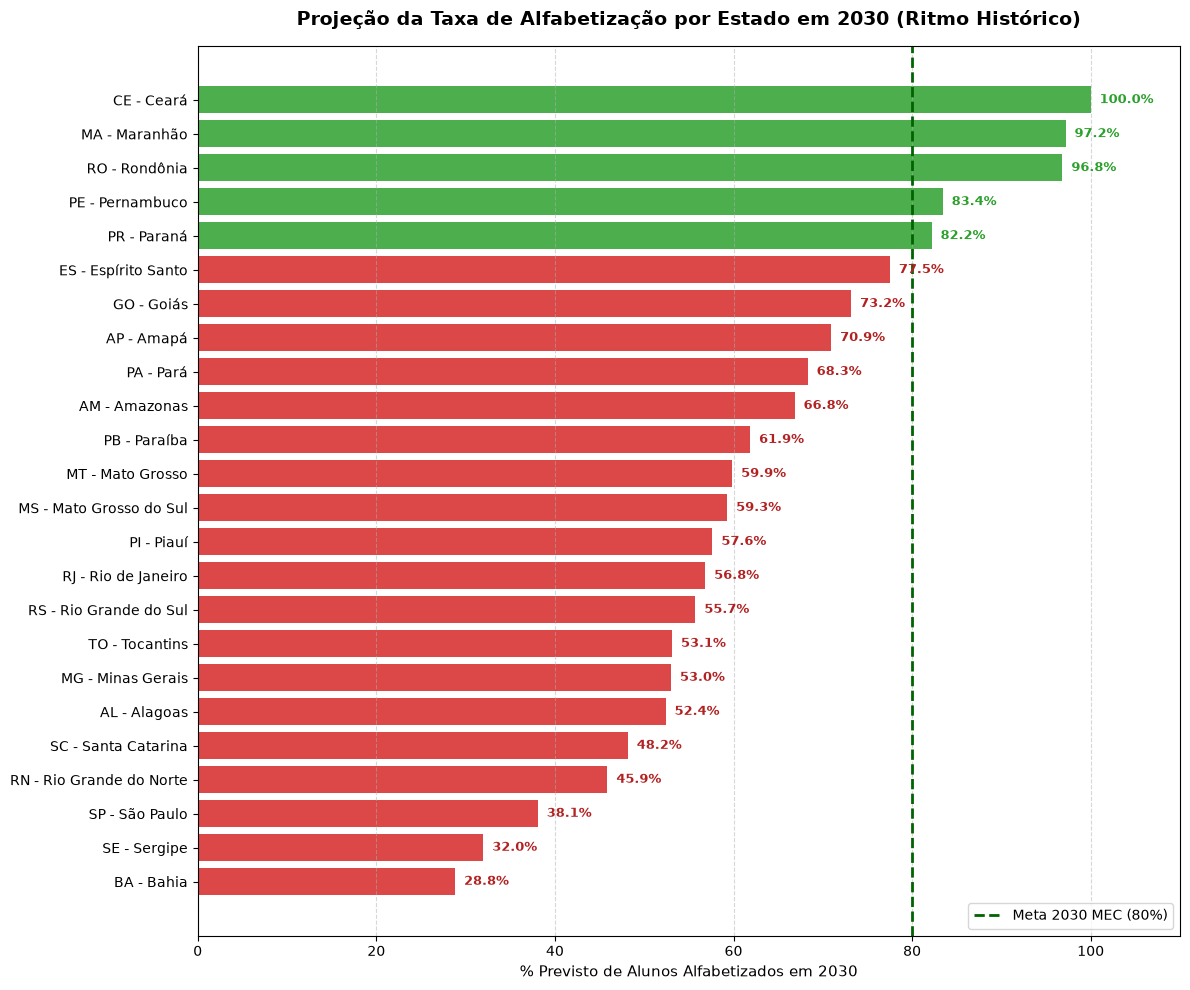

Apenas 5 de 24 estados (20.8%) atingirão a meta de 80% no ritmo atual.


In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filtra os dados de 2023 por estado
df_ufs = resultado_metas[
    (resultado_metas["NU_ANO_AVALIACAO"] == 2023) & 
    (resultado_metas["SIGLA_UF"].notnull()) & 
    (~resultado_metas["SIGLA_UF"].isin(["SC*"]))
].copy()

# Calcula ritmo anual (2019 a 2023) e projeta até 2030 (limitando a 100%)
df_ufs["RITMO_ANUAL"] = (df_ufs["PC_ALUNO_ALFABETIZADO"] - df_ufs["SAEB_2019"]) / 4.0
df_ufs["PROJ_2030"] = (df_ufs["PC_ALUNO_ALFABETIZADO"] + df_ufs["RITMO_ANUAL"] * 7.0).clip(lower=0, upper=100.0)

# Filtra estados com dados válidos e ordena do menor para o maior
df_plot = df_ufs.dropna(subset=["PROJ_2030"]).sort_values("PROJ_2030", ascending=True)

# Cores: Verde para quem atinge >= 80% e Coral/Vermelho para quem fica abaixo
cores = ["#2ca02c" if val >= 80 else "#d62728" for val in df_plot["PROJ_2030"]]

# Gráfico de Barras Horizontais
plt.figure(figsize=(12, 10))
barras = plt.barh(df_plot["SIGLA_UF"] + " - " + df_plot["NOME_UF"], df_plot["PROJ_2030"], color=cores, alpha=0.85)

# Linha de corte da Meta 2030 (80%)
plt.axvline(80, color="darkgreen", linestyle="--", lw=2, label="Meta 2030 MEC (80%)")

# Rótulos com os valores em cada barra
for barra in barras:
    w = barra.get_width()
    plt.text(w + 1, barra.get_y() + barra.get_height()/2, f"{w:.1f}%", 
             va='center', ha='left', fontsize=9, fontweight='bold',
             color="#2ca02c" if w >= 80 else "#b22222")

plt.title("Projeção da Taxa de Alfabetização por Estado em 2030 (Ritmo Histórico)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("% Previsto de Alunos Alfabetizados em 2030", fontsize=11)
plt.xlim(0, 110)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Resumo executivo
atingem = (df_plot["PROJ_2030"] >= 80).sum()
total = len(df_plot)
print(f"Apenas {atingem} de {total} estados ({atingem/total*100:.1f}%) atingirão a meta de 80% no ritmo atual.")


In [110]:
import shap
import matplotlib.pyplot as plt

# Amostra para interpretação
X_shap = X_test_prof.sample(
    n=5000,
    random_state=42
)

X_shap.shape

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(5000, 21)

In [116]:
shap_values_classe1 = shap_values.values[:, :, 1]
print(shap_values_classe1.shape)

(5000, 21)


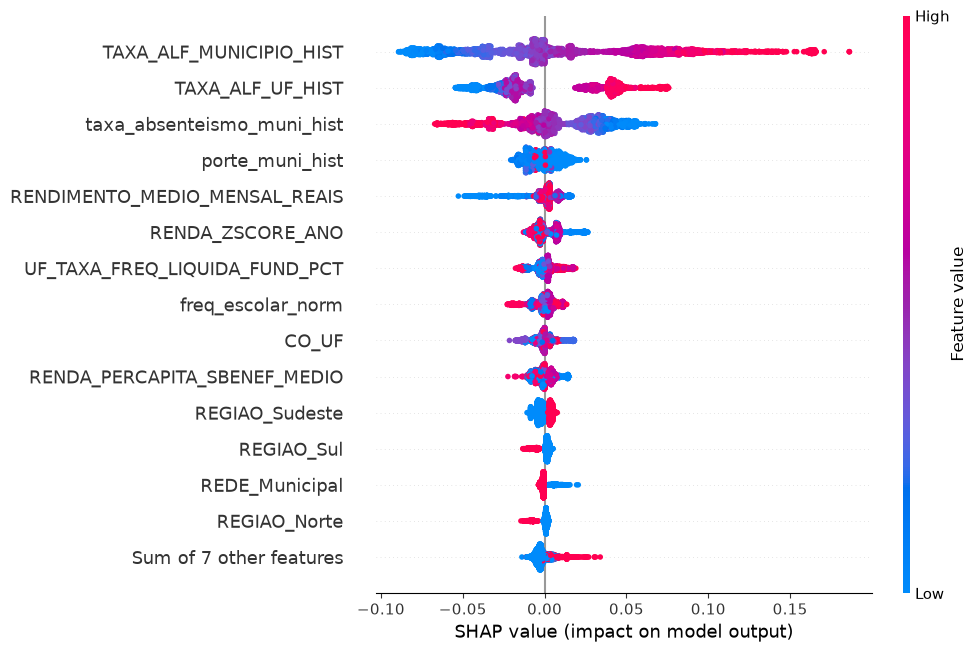

In [117]:
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values_classe1,
        base_values=shap_values.base_values[:, 1],
        data=X_shap.values,
        feature_names=X_shap.columns.tolist()
    ),
    max_display=15
)


A análise SHAP mostrou que o histórico de alfabetização municipal é o principal fator associado às previsões do modelo. O histórico da UF também apresenta forte influência, enquanto o absenteísmo histórico municipal aparece como importante fator associado negativamente ao desempenho previsto. Variáveis socioeconômicas e territoriais complementam a explicação das previsões.

1. Persistência territorial:
o desempenho histórico do município é o principal sinal utilizado pelo modelo.

2. Frequência importa:
maior absenteísmo histórico aparece associado a pior previsão.

3. Contexto socioeconômico complementa:
renda, frequência e características territoriais ajudam a diferenciar as previsões.

# old - but gold

### <font color="green">Feat Engenering Modelo 2</font>

In [133]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import lightgbm as lgb_lib
import xgboost as xgb_lib
from xgboost import XGBRegressor

from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)



In [134]:
df_modelo = carregar_parquet_s3(s3_client=s3,bucket=BUCKET,nome_tabela="tabela_modelo_v2",subpasta="modelo")

Lendo: s3://postech-challenge-datascience-003/gold/modelo/tabela_modelo_v2.parquet


In [ ]:
# REDE → OneHotEncoding 
mapa_dependencia = {1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"}
df_modelo["REDE"] = df_modelo["TP_DEPENDENCIA"].map(mapa_dependencia)
cat_encoder = OneHotEncoder(sparse_output=False, dtype=int)
rede_1hot = cat_encoder.fit_transform(df_modelo[["REDE"]])
colunas_nomes = cat_encoder.get_feature_names_out(["REDE"])
df_rede_1hot = pd.DataFrame(rede_1hot, columns=colunas_nomes, index=df_modelo.index)
df_modelo = pd.concat([df_modelo, df_rede_1hot], axis=1)

# Features de Escola 
df_modelo["IN_AUSENTE"] = (df_modelo["IN_PRESENCA_LP"] == 0).astype("int8")
df_modelo["porte_escola_alunos"]       = df_modelo.groupby("ID_ESCOLA")["IN_PRESENCA_LP"].transform("count")
df_modelo["taxa_absenteismo_escola"]   = df_modelo.groupby("ID_ESCOLA")["IN_AUSENTE"].transform("mean")
df_modelo["taxa_preenchimento_escola"] = df_modelo.groupby("ID_ESCOLA")["IN_PREENCHIMENTO_LP"].transform("mean")
df_modelo["freq_escolar_norm"]         = df_modelo["UF_TAXA_FREQ_LIQUIDA_FUND_PCT"] / 100.0

# Features de Município 
df_modelo["porte_muni_alunos"]     = df_modelo.groupby("CO_MUNICIPIO")["IN_PRESENCA_LP"].transform("count")
df_modelo["taxa_absenteismo_muni"] = df_modelo.groupby("CO_MUNICIPIO")["IN_AUSENTE"].transform("mean")

# Renda Z-Score por Ano 
df_modelo["RENDA_ZSCORE_ANO"] = (
    df_modelo.groupby("NU_ANO_AVALIACAO")["RENDA_PERCAPITA_SBENEF_MEDIO"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

#  Região → OneHotEncoding 
mapa_co_uf_regiao = {
    11: "Norte", 12: "Norte", 13: "Norte", 14: "Norte", 15: "Norte", 16: "Norte", 17: "Norte",
    21: "Nordeste", 22: "Nordeste", 23: "Nordeste", 24: "Nordeste", 25: "Nordeste", 26: "Nordeste",
    27: "Nordeste", 28: "Nordeste", 29: "Nordeste",
    31: "Sudeste", 32: "Sudeste", 33: "Sudeste", 35: "Sudeste",
    41: "Sul", 42: "Sul", 43: "Sul",
    50: "Centro-Oeste", 51: "Centro-Oeste", 52: "Centro-Oeste", 53: "Centro-Oeste"
}
df_modelo["REGIAO"] = df_modelo["CO_UF"].map(mapa_co_uf_regiao)
df_regiao_1hot = pd.get_dummies(df_modelo["REGIAO"], prefix="REGIAO", dtype="int8")
df_modelo = pd.concat([df_modelo, df_regiao_1hot], axis=1)

# ── Log-porte ────────────
df_modelo["log_porte_escola"] = np.log1p(df_modelo["porte_escola_alunos"])
df_modelo["log_porte_muni"]   = np.log1p(df_modelo["porte_muni_alunos"])


# NOVAS FEATURES — Contexto Municipal e Estadual

# Proficiência do município normalizada (Z-Score por ano)
df_modelo["PROF_MUNI_ZSCORE"] = (
    df_modelo.groupby("NU_ANO_AVALIACAO")["VL_MEDIA_LP_TOTAL_MUNICIPIO"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

#  Município vs média estadual (momentum relativo)
df_modelo["MUNI_VS_UF"] = (
    df_modelo["PC_ALUNO_ALFABETIZADO_TOTAL_MUNICIPIO"] -
    df_modelo["PC_ALUNO_ALFABETIZADO_TOTAL_UF"]
)

#Proficiência do município relativa ao estado
df_modelo["PROF_MUNI_RELATIVA_UF"] = (
    df_modelo["VL_MEDIA_LP_TOTAL_MUNICIPIO"] /
    (df_modelo["VL_MEDIA_LP_TOTAL_UF"] + 1e-6)
)

# Engajamento da escola vs município
df_modelo["ESCOLA_VS_MUNI_ABSENTEISMO"] = (
    df_modelo["taxa_absenteismo_escola"] - df_modelo["taxa_absenteismo_muni"]
)

# Flag de ano pandemia
df_modelo["ANO_PANDEMIA"] = (df_modelo["NU_ANO_AVALIACAO"] == 2021).astype("int8")

#  Verificação 
print("Feature engineering completo!")
print(f"Shape final: {df_modelo.shape}")
print("Nulos nas novas features:")
novas = ["PROF_MUNI_ZSCORE",  "MUNI_VS_UF",
         "PROF_MUNI_RELATIVA_UF", "ESCOLA_VS_MUNI_ABSENTEISMO", "ANO_PANDEMIA"]
print(df_modelo[novas].isna().sum())


Feature engineering completo!
Shape final: (6090791, 41)
Nulos nas novas features:
PROF_MUNI_ZSCORE               3929
MUNI_VS_UF                    31627
PROF_MUNI_RELATIVA_UF         31627
ESCOLA_VS_MUNI_ABSENTEISMO      628
ANO_PANDEMIA                      0
dtype: int64


In [ ]:
# PROF_MUNI_ZSCORE = 0
# → Municípios sem dado SAEB assumem proficiência igual à média nacional
df_modelo["PROF_MUNI_ZSCORE"] = df_modelo["PROF_MUNI_ZSCORE"].fillna(0.0)

# MUNI_VS_UF = 0
# → Municípios sem dado estadual assumem que estão igual ao seu estado (neutro)
df_modelo["MUNI_VS_UF"] = df_modelo["MUNI_VS_UF"].fillna(0.0)

# PROF_MUNI_RELATIVA_UF = 1.0
# → Municípios sem dado estadual assumem proficiência = 100% do estado (neutro)
df_modelo["PROF_MUNI_RELATIVA_UF"] = df_modelo["PROF_MUNI_RELATIVA_UF"].fillna(1.0)

# ESCOLA_VS_MUNI_ABSENTEISMO = 0
# → Escolas sem dado assumem absenteísmo igual ao município (neutro)
df_modelo["ESCOLA_VS_MUNI_ABSENTEISMO"] = df_modelo["ESCOLA_VS_MUNI_ABSENTEISMO"].fillna(0.0)

# ── Verificação final ─────────────────────────────────────────────
novas = ["PROF_MUNI_ZSCORE", "MUNI_VS_UF",
         "PROF_MUNI_RELATIVA_UF", "ESCOLA_VS_MUNI_ABSENTEISMO", "ANO_PANDEMIA"]

print(" Nulos após imputação:")
print(df_modelo[novas].isna().sum())

 Nulos após imputação:
PROF_MUNI_ZSCORE              0
MUNI_VS_UF                    0
PROF_MUNI_RELATIVA_UF         0
ESCOLA_VS_MUNI_ABSENTEISMO    0
ANO_PANDEMIA                  0
dtype: int64


### <font color="green">Treino Modelo 2</font>

In [ ]:
features = [
    # TARGET
    "IN_ALFABETIZADO",

    # Escola
    "taxa_absenteismo_escola",
    "taxa_preenchimento_escola",
    "log_porte_escola",

    # Município
    "taxa_absenteismo_muni",
    "log_porte_muni",

    # 🆕 Contexto SAEB Municipal e Estadual
    #"PROF_MUNI_ZSCORE",
    
    "MUNI_VS_UF",
    "PROF_MUNI_RELATIVA_UF",
    "ESCOLA_VS_MUNI_ABSENTEISMO",

    # Rede
    "REDE_Estadual", "REDE_Municipal", "REDE_Privada",

    # Socioeconômico
    "RENDA_ZSCORE_ANO",
    "freq_escolar_norm",

    # 🆕 Temporal
    "ANO_PANDEMIA",

    # Regiões
    "REGIAO_Centro-Oeste", "REGIAO_Nordeste",
    "REGIAO_Norte", "REGIAO_Sudeste", "REGIAO_Sul",
]


In [ ]:
df_treino = df_modelo[features].dropna().copy()

y = df_treino["IN_ALFABETIZADO"]
X = df_treino.drop(columns=["IN_ALFABETIZADO"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# 3. BASELINE

classe_majoritaria = y_train.mode()[0]
y_pred_baseline = np.full(len(y_test), classe_majoritaria)
avaliar("Baseline (Maioria)", y_test, y_pred_baseline)


  Baseline (Maioria)
  Acurácia : 0.5398
  Precisão : 0.5398
  Recall   : 1.0000
  F1-Score : 0.7011


In [ ]:
# RANDOM FOREST  
print(" Buscando hiperparâmetros da Random Forest...")

param_dist_rf = {
    "n_estimators":      [200, 300, 500],
    "max_depth":         [8, 12, 16, 20],
    "min_samples_split": [10, 20, 50],
    "min_samples_leaf":  [5, 10, 20],
    "max_features":      ["sqrt", 0.5, 0.7],
}

X_sample_rf = X_train.sample(n=min(100_000, len(X_train)), random_state=42)
y_sample_rf = y_train.loc[X_sample_rf.index]

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=15,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
random_search_rf.fit(X_sample_rf, y_sample_rf)
print(f"  Melhores params RF : {random_search_rf.best_params_}")
print(f"  AUC-ROC (val)      : {random_search_rf.best_score_:.4f}")

modelo_rf = RandomForestClassifier(
    **random_search_rf.best_params_,
    n_jobs=-1,
    random_state=42,
)
modelo_rf.fit(X_train, y_train)

y_pred_rf   = modelo_rf.predict(X_test)
y_proba_rf  = modelo_rf.predict_proba(X_test)[:, 1]
avaliar("Random Forest (CPU)", y_test, y_pred_rf, y_proba_rf)

 Buscando hiperparâmetros da Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  Melhores params RF : {'n_estimators': 200, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 0.5, 'max_depth': 12}
  AUC-ROC (val)      : 0.6712


In [ ]:
# XGBOOST 

print("Treinando XGBoost ")

modelo_xgb = xgb_lib.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    device="cuda",               #   GPU 
    early_stopping_rounds=20,
    eval_metric="auc",
    random_state=42,
    verbosity=0,
)
modelo_xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)
print(f"  Melhor iteração XGB: {modelo_xgb.best_iteration}")

y_pred_xgb  = modelo_xgb.predict(X_test)
y_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]
avaliar("XGBoost (GPU CUDA)", y_test, y_pred_xgb, y_proba_xgb)

Treinando XGBoost 
[0]	validation_0-auc:0.64930
[100]	validation_0-auc:0.68091
[200]	validation_0-auc:0.68389
[300]	validation_0-auc:0.68522
[400]	validation_0-auc:0.68601
[500]	validation_0-auc:0.68669
[600]	validation_0-auc:0.68735
[700]	validation_0-auc:0.68790
[800]	validation_0-auc:0.68844
[900]	validation_0-auc:0.68895
[999]	validation_0-auc:0.68941
  Melhor iteração XGB: 999

  XGBoost (GPU CUDA)
  Acurácia : 0.6357
  Precisão : 0.6498
  Recall   : 0.7048
  F1-Score : 0.6762
  AUC-ROC  : 0.6894


In [ ]:
# LIGHTGBM 
print(" Treinando LightGBM (CPU multi-thread)...")

modelo_lgbm = lgb_lib.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    # device="gpu"  ← pip wheel não compila com GPU;
    n_jobs=-1,       # usa todos os núcleos disponíveis
    random_state=42,
    verbose=-1,
)
modelo_lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc",
    callbacks=[
        lgb_lib.early_stopping(stopping_rounds=20, verbose=False),
        lgb_lib.log_evaluation(period=100),
    ],
)
print(f"  Melhor iteração LGBM: {modelo_lgbm.best_iteration_}")

y_pred_lgbm  = modelo_lgbm.predict(X_test)
y_proba_lgbm = modelo_lgbm.predict_proba(X_test)[:, 1]
avaliar("LightGBM (CPU n_jobs=-1)", y_test, y_pred_lgbm, y_proba_lgbm)


 Treinando LightGBM (CPU multi-thread)...


c:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's auc: 0.682191	valid_0's binary_logloss: 0.63478
[200]	valid_0's auc: 0.684693	valid_0's binary_logloss: 0.632918
[300]	valid_0's auc: 0.68582	valid_0's binary_logloss: 0.632149
[400]	valid_0's auc: 0.686678	valid_0's binary_logloss: 0.631581
[500]	valid_0's auc: 0.687475	valid_0's binary_logloss: 0.631084
[600]	valid_0's auc: 0.688151	valid_0's binary_logloss: 0.630656
[700]	valid_0's auc: 0.688752	valid_0's binary_logloss: 0.630279
[800]	valid_0's auc: 0.689322	valid_0's binary_logloss: 0.629922
[900]	valid_0's auc: 0.689955	valid_0's binary_logloss: 0.62954
[1000]	valid_0's auc: 0.690521	valid_0's binary_logloss: 0.629188
  Melhor iteração LGBM: 1000

  LightGBM (CPU n_jobs=-1)
  Acurácia : 0.6364
  Precisão : 0.6502
  Recall   : 0.7065
  F1-Score : 0.6772
  AUC-ROC  : 0.6905


In [ ]:
import joblib

# Garante que a pasta models existe
os.makedirs("models", exist_ok=True)

# Salva o modelo treinado
caminho_local = "models/modelo_lgbm_profundo.joblib"
joblib.dump(modelo_lgbm_profundo, caminho_local)

tamanho_mb = os.path.getsize(caminho_local) / (1024 * 1024)
print(f"Modelo LGBM  salvo com sucesso em: {caminho_local} ({tamanho_mb:.2f} MB)")

#SALVAR NO S3 
caminho_s3 = "models/modelo_lgbm_profundo.joblib"

# Faz o upload do arquivo salvo para o bucket
s3.upload_file(caminho_local, BUCKET, caminho_s3)
print(f" Modelo enviado com sucesso para s3://{BUCKET}/{caminho_s3}!")


# Salva X_test e y_test compactados em parquet ou joblib
X_test.to_parquet("models/X_test_2.parquet")
y_test.to_frame().to_parquet("models/y_test_2.parquet")
print("Dados de teste salvos com sucesso!")


Modelo LGBM  salvo com sucesso em: models/modelo_lgbm_profundo.joblib (40.13 MB)
 Modelo enviado com sucesso para s3://postech-challenge-datascience-003/models/modelo_lgbm_profundo.joblib!
Dados de teste salvos com sucesso!


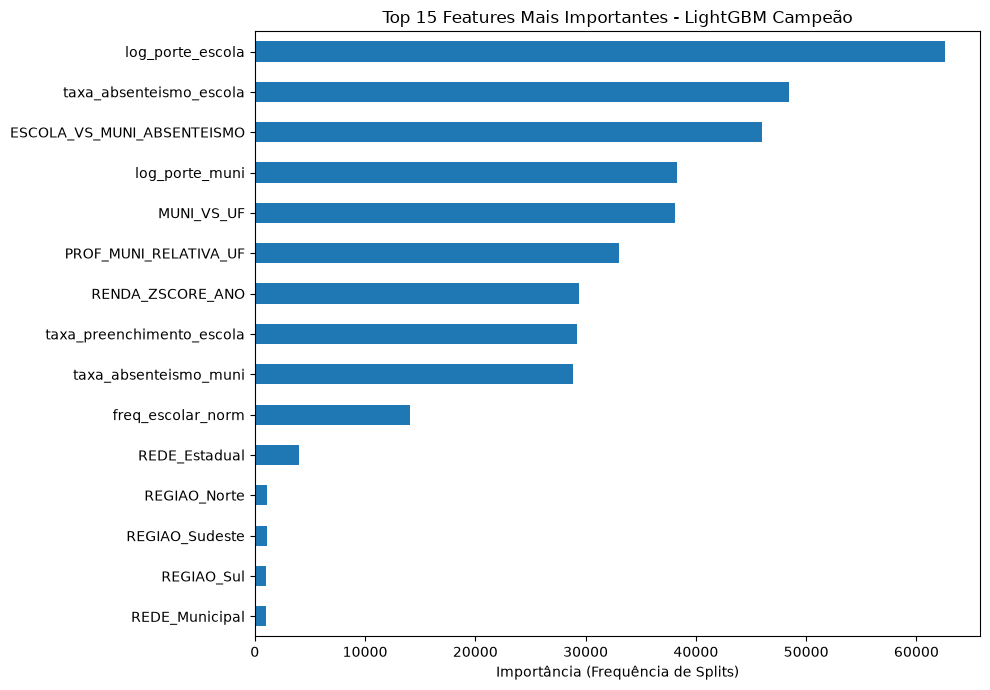

log_porte_escola              62633
taxa_absenteismo_escola       48423
ESCOLA_VS_MUNI_ABSENTEISMO    46003
log_porte_muni                38297
MUNI_VS_UF                    38114
PROF_MUNI_RELATIVA_UF         33023
RENDA_ZSCORE_ANO              29443
taxa_preenchimento_escola     29262
taxa_absenteismo_muni         28895
freq_escolar_norm             14059
REDE_Estadual                  4051
REGIAO_Norte                   1129
REGIAO_Sudeste                 1065
REGIAO_Sul                     1025
REDE_Municipal                  982
REGIAO_Nordeste                 900
REGIAO_Centro-Oeste             676
REDE_Privada                      0
ANO_PANDEMIA                      0
dtype: int32


In [ ]:
# Usa diretamente os nomes das features do modelo treinado
nomes_features = getattr(
    modelo_lgbm_profundo, "feature_name_", X_train.columns
)

importancias = pd.Series(
    modelo_lgbm_profundo.feature_importances_, index=nomes_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importancias.head(15).plot(kind="barh", color="#1f77b4")
plt.gca().invert_yaxis()
plt.title("Top 15 Features Mais Importantes - LightGBM Campeão")
plt.xlabel("Importância (Frequência de Splits)")
plt.tight_layout()
plt.show()

# Exibir os valores exatos em texto
print(importancias)


### <font color="green">Avaliação Modelo </font>

In [ ]:
from src.data.utils import carregar_modelo, fazer_previsoes

# Carrega os dados de teste salvos
X_test = pd.read_parquet("models/X_test_2.parquet")
y_test = pd.read_parquet("models/y_test_2.parquet")["IN_ALFABETIZADO"]

# Carrega com resolução automática de caminho:
lgbm = carregar_modelo("modelo_lgbm_profundo.joblib")

# Faz as previsões:
novas_previsoes = lgbm.predict(X_test)
print(f"Previsões geradas com sucesso! Qtd: {len(novas_previsoes)}")


📦 Modelo carregado com sucesso de: C:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\notebooks\models\modelo_lgbm_profundo.joblib
Previsões geradas com sucesso! Qtd: 1218033


In [ ]:
# 2. Classe final: 0 ou 1
pred_classes = lgbm.predict(X_test)

# 3. Probabilidade (ex: 0.82 = 82% de chance de ser alfabetizado)
pred_probabilidades = lgbm.predict_proba(X_test)[:, 1]


In [ ]:
import pandas as pd

# Cria uma tabela com os alunos e as previsões do modelo
df_analise = X_test.copy()
df_analise["PREV_ALFABETIZADO"] = lgbm.predict(X_test)
df_analise["PROB_ALFABETIZADO"] = lgbm.predict_proba(X_test)[:, 1]

# Taxa geral prevista pelo modelo no teste:
taxa_geral_prevista = df_analise["PREV_ALFABETIZADO"].mean() * 100
print(f"Taxa de Alfabetização Prevista pelo LightGBM: {taxa_geral_prevista:.2f}%")




Taxa de Alfabetização Prevista pelo LightGBM: 58.10%


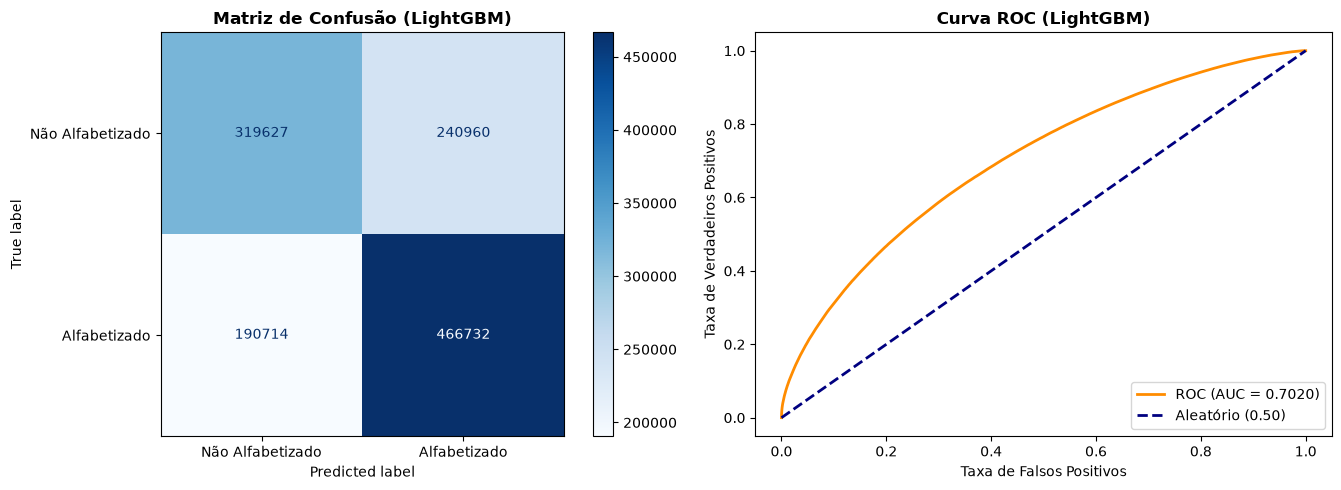

In [ ]:
plot_classificacao(lgbm, X_test, y_test, model_name="LightGBM")

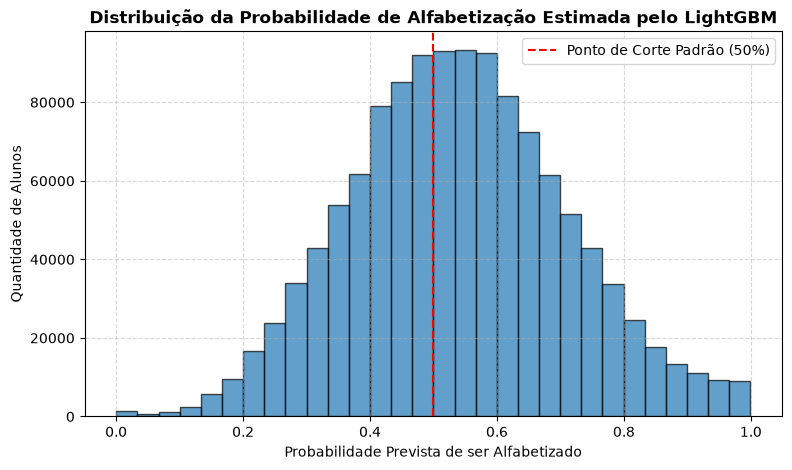

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.hist(pred_probabilidades, bins=30, color="#1f77b4", edgecolor="black", alpha=0.7)
plt.axvline(0.5, color="red", linestyle="--", label="Ponto de Corte Padrão (50%)")
plt.title("Distribuição da Probabilidade de Alfabetização Estimada pelo LightGBM", fontsize=12, fontweight='bold')
plt.xlabel("Probabilidade Prevista de ser Alfabetizado")
plt.ylabel("Quantidade de Alunos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Esse gráfico de distribuição nos diz que temos uma faixa entre 45 e 65% de probabilidade de um aluno ser alfabetizado no Brasil. 

In [ ]:
import pandas as pd
import numpy as np

# Cria faixas de probabilidade de 10 em 10%
faixas = pd.cut(
    pred_probabilidades, 
    bins=np.linspace(0, 1, 11), 
    labels=[f"{int(i*10)}% a {int((i+1)*10)}%" for i in range(10)]
)


tabela_faixas = pd.DataFrame({
    "Faixa_Probabilidade": faixas,
    "Real_Alfabetizado": y_test.values
})

resumo_faixas = tabela_faixas.groupby("Faixa_Probabilidade", observed=False).agg(
    Qtd_Alunos=("Real_Alfabetizado", "count"),
    Qtd_Alfabetizados_Reais=("Real_Alfabetizado", "sum"),
    Taxa_Real_Alfabetizados=("Real_Alfabetizado", "mean")
)

resumo_faixas["Taxa_Real_Alfabetizados (%)"] = (resumo_faixas["Taxa_Real_Alfabetizados"] * 100).round(2)
resumo_faixas["% do Total de Alunos"] = ((resumo_faixas["Qtd_Alunos"] / len(y_test)) * 100).round(2)

print("Tabela de Calibração por Faixa de Probabilidade:")
display(resumo_faixas[["Qtd_Alunos", "% do Total de Alunos", "Taxa_Real_Alfabetizados (%)"]])


Tabela de Calibração por Faixa de Probabilidade:


,Qtd_Alunos,% do Total de Alunos,Taxa_Real_Alfabetizados (%)
Faixa_Probabilidade,,,
0% a 10%,3162,0.26,3.10
10% a 20%,17498,1.44,15.16
20% a 30%,74463,6.11,24.66
30% a 40%,158691,13.03,34.59
40% a 50%,256527,21.06,44.71
50% a 60%,279394,22.94,55.10
60% a 70%,215221,17.67,65.67
70% a 80%,128045,10.51,75.44
80% a 90%,55638,4.57,84.62


In [ ]:
# Filtra os dois extremos
alunos_alta_prob = X_test[pred_probabilidades >= 0.85]
alunos_baixa_prob = X_test[pred_probabilidades <= 0.25]

print(f"Alunos com Probabilidade >= 85%: {len(alunos_alta_prob):,} alunos")
print(f"Alunos com Probabilidade <= 25%: {len(alunos_baixa_prob):,} alunos")

# Compara as médias das principais colunas numéricas
comparativo_extremos = pd.DataFrame({
    "Perfil Alta Probabilidade (>85%)": alunos_alta_prob.mean(numeric_only=True),
    "Perfil Baixa Probabilidade (<25%)": alunos_baixa_prob.mean(numeric_only=True)
})

comparativo_extremos["Diferença"] = comparativo_extremos["Perfil Alta Probabilidade (>85%)"] - comparativo_extremos["Perfil Baixa Probabilidade (<25%)"]

# Exibe as 10 features com maior contraste entre os dois mundos:
display(comparativo_extremos.sort_values(by="Diferença", ascending=False).head(10))


Alunos com Probabilidade >= 85%: 50,559 alunos
Alunos com Probabilidade <= 25%: 48,132 alunos


,Perfil Alta Probabilidade (>85%),Perfil Baixa Probabilidade (<25%),Diferença
MUNI_VS_UF,16.283149,-12.127810,28.410959
REGIAO_Nordeste,0.712119,0.474591,0.237528
taxa_preenchimento_escola,0.947698,0.789685,0.158013
REGIAO_Centro-Oeste,0.098380,0.034011,0.064369
REDE_Municipal,0.957772,0.904305,0.053467
PROF_MUNI_RELATIVA_UF,1.034028,0.983210,0.050818
REGIAO_Sudeste,0.115271,0.103694,0.011577
freq_escolar_norm,0.912603,0.907607,0.004995
REDE_Privada,0.000000,0.000000,0.000000
ANO_PANDEMIA,0.000000,0.000000,0.000000


**MUNI_VS_UF** -> Os municipios em que a média está acima da média estadual pontuam muito acima, o estudo das politicas desses municipios serão importantes para uma avaliação de como melhorar o indicide de alfabetização e reproduzir para o restante do País. Porém também temos o problema inverso.  

> O "Efeito Município" é decisivo. O fator determinante para uma criança se alfabetizar não é apenas a escola dela, mas a qualidade da gestão da Secretaria Municipal de Educação. Estar em um município com boa gestão eleva drasticamente a chance de alfabetização da criança.


**PROF_MUNI_ZSCORE** -> Essa métrica de Z-score serve para visualizar o quão longe o municipio está da média do Brasil (utilizando o desvio padrão). 
aqui se indica que a probabilidade de mais de 85% de alfabetização se cnoncetra em Municipios que estão no topo da média brasileira. 
> Novamente temos uma prova de que as politicas municipais influenciam diretamente a qualidade da alfabetização, podemos dizer que o Municipio tem grande impacto na alfabetização brasileira 

**REGIAO_Nordeste** -> Essa métrica nos diz que 70% dos alunos com mais de 85% de chance de estar alfabetizado está no Nordeste 
> Aqui temos um padrão regional, existe um impacto grande que supera o municipio 

**taxa_preenchimento_escola** -> essa métrica nos diz que escolas com os melhores alunos preenchem 94% dos questionários. Escolas dos alunos em risco deixam mais de 20% em branco.

**REDE_Municipal** -> Essa métrica nos diz que 95% dos alunos com maior probabilidade de ser alfabetizado estão na rede municipal, entendemos que isso pode ser refletido pela quantidade mais abundante de alunos dessa região, ainda assim é uma métrica importante

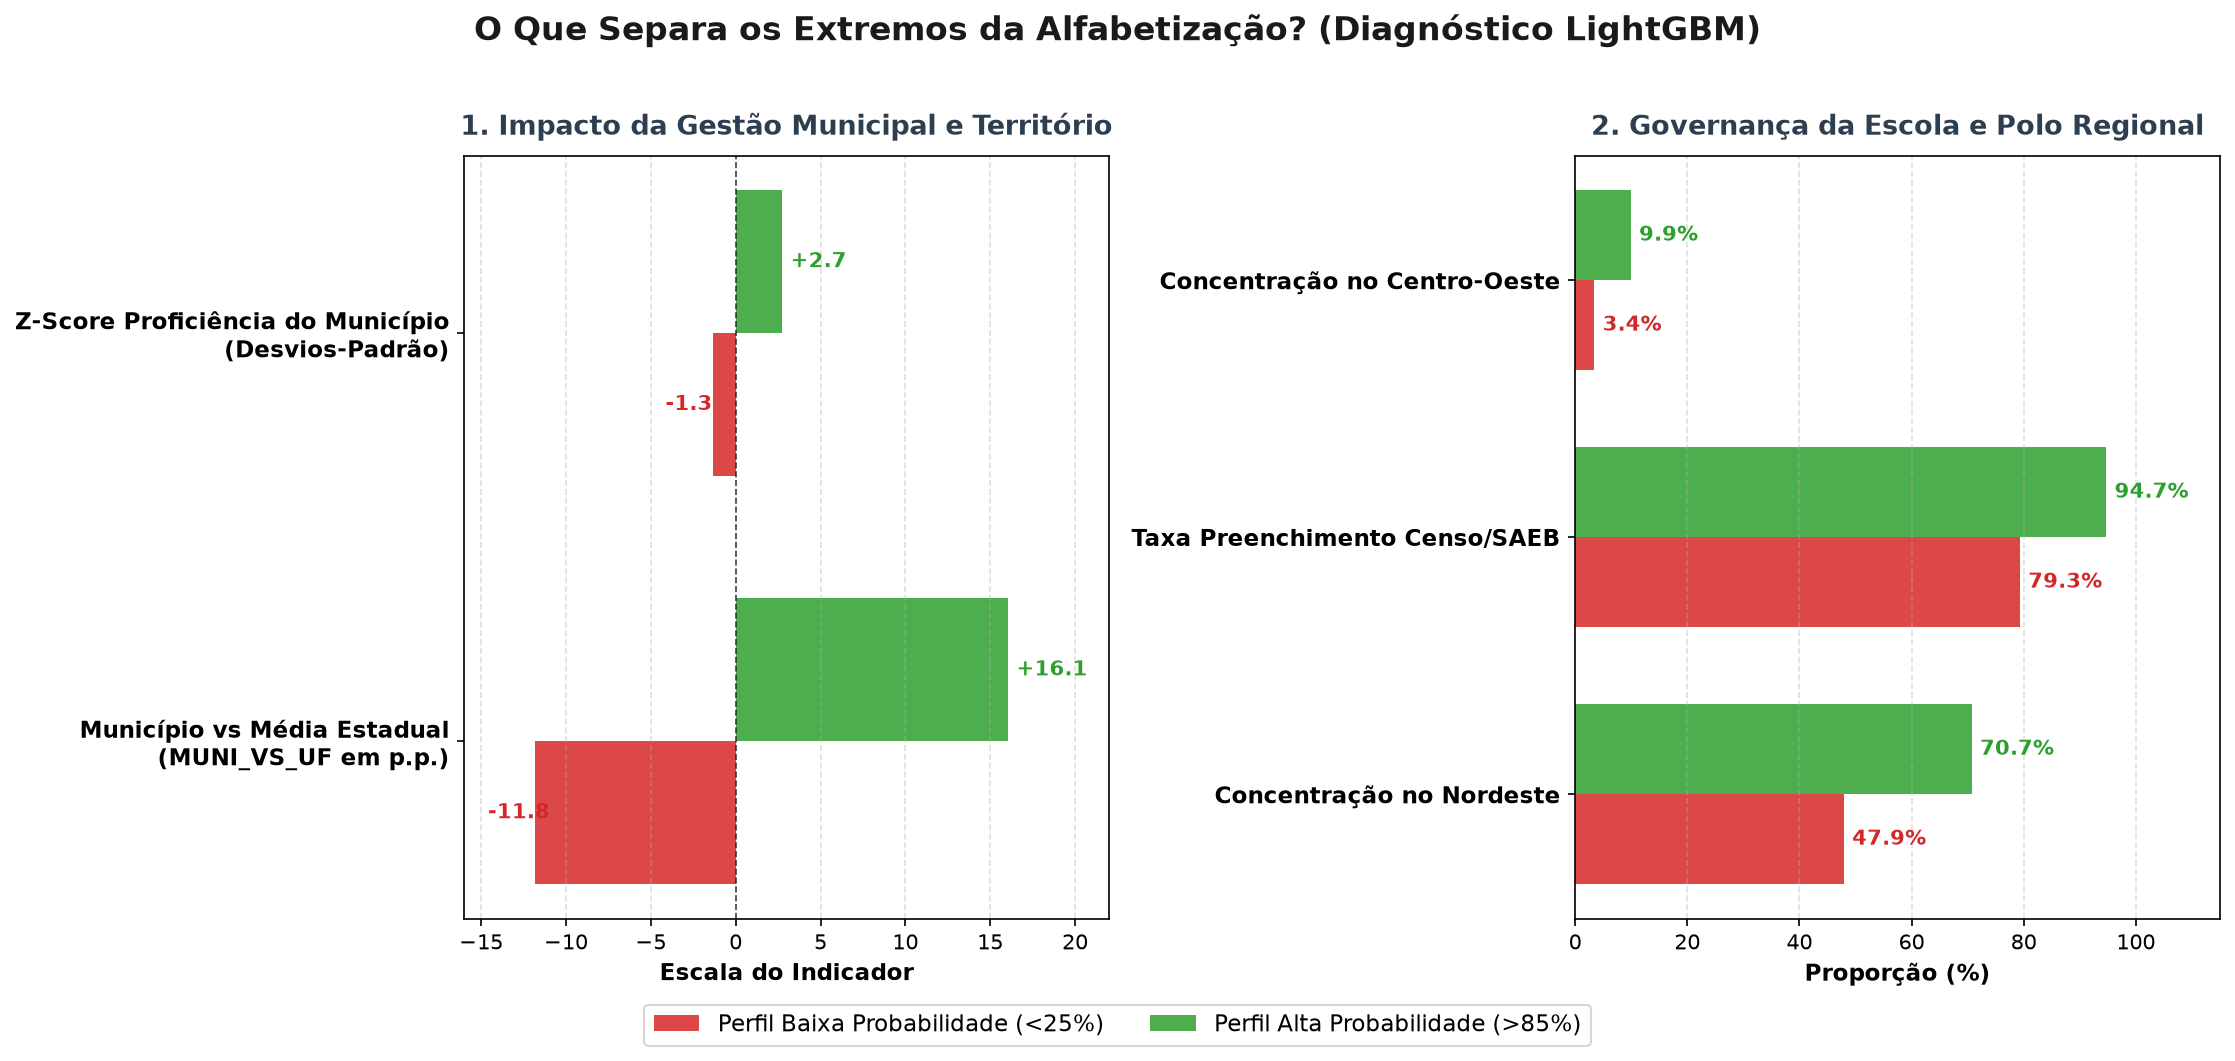

✅ Gráfico gerado e salvo como 'grafico_perfil_extremos_powerpoint.png'!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Dados extraídos do seu teste ──────────────────────────────────────────
# Grupo 1: Indicadores Municipais
labels_muni = [
    "Município vs Média Estadual\n(MUNI_VS_UF em p.p.)",
    "Z-Score Proficiência do Município\n(Desvios-Padrão)"
]
alta_muni = [16.05, 2.74]
baixa_muni = [-11.80, -1.34]

# Grupo 2: Indicadores Estruturais e Regionais (%)
labels_perc = [
    "Concentração no Nordeste",
    "Taxa Preenchimento Censo/SAEB",
    "Concentração no Centro-Oeste"
]
alta_perc = [70.7, 94.7, 9.9]
baixa_perc = [47.9, 79.3, 3.4]

# ── 2. Configuração do Gráfico para PowerPoint (16:9) ───────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5), dpi=150)
fig.suptitle(
    "O Que Separa os Extremos da Alfabetização? (Diagnóstico LightGBM)",
    fontsize=16, fontweight="bold", y=1.02, color="#1a1a1a"
)

cor_alta = "#2ca02c"   # Verde Sucesso
cor_baixa = "#d62728"  # Vermelho Alerta
largura = 0.35

# ── PAINEL 1: O Efeito da Gestão Municipal ──────────────────────────────────
y1 = np.arange(len(labels_muni))
rects1_b = ax1.barh(y1 - largura/2, baixa_muni, largura, label="Perfil Baixa Probabilidade (<25%)", color=cor_baixa, alpha=0.85)
rects1_a = ax1.barh(y1 + largura/2, alta_muni, largura, label="Perfil Alta Probabilidade (>85%)", color=cor_alta, alpha=0.85)

ax1.axvline(0, color="black", linestyle="--", lw=0.8, alpha=0.7)
ax1.set_yticks(y1)
ax1.set_yticklabels(labels_muni, fontsize=11, fontweight="bold")
ax1.set_xlabel("Escala do Indicador", fontsize=11, fontweight="bold")
ax1.set_title("1. Impacto da Gestão Municipal e Território", fontsize=13, fontweight="bold", pad=10, color="#2c3e50")
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax1.set_xlim(-16, 22)

# Rótulos de valores nas barras
for r in rects1_b:
    w = r.get_width()
    ax1.annotate(f"{w:+.1f}", (w - 2.8 if w < 0 else w + 0.5, r.get_y() + r.get_height()/2),
                 va='center', fontsize=10, fontweight='bold', color=cor_baixa)
for r in rects1_a:
    w = r.get_width()
    ax1.annotate(f"{w:+.1f}", (w + 0.5, r.get_y() + r.get_height()/2),
                 va='center', fontsize=10, fontweight='bold', color=cor_alta)

# ── PAINEL 2: Governança Escolar e Regional ─────────────────────────────────
y2 = np.arange(len(labels_perc))
rects2_b = ax2.barh(y2 - largura/2, baixa_perc, largura, label="Perfil Baixa Probabilidade (<25%)", color=cor_baixa, alpha=0.85)
rects2_a = ax2.barh(y2 + largura/2, alta_perc, largura, label="Perfil Alta Probabilidade (>85%)", color=cor_alta, alpha=0.85)

ax2.set_yticks(y2)
ax2.set_yticklabels(labels_perc, fontsize=11, fontweight="bold")
ax2.set_xlabel("Proporção (%)", fontsize=11, fontweight="bold")
ax2.set_title("2. Governança da Escola e Polo Regional", fontsize=13, fontweight="bold", pad=10, color="#2c3e50")
ax2.grid(axis="x", linestyle="--", alpha=0.4)
ax2.set_xlim(0, 115)

# Rótulos de valores nas barras
for r in rects2_b:
    w = r.get_width()
    ax2.annotate(f"{w:.1f}%", (w + 1.5, r.get_y() + r.get_height()/2),
                 va='center', fontsize=10, fontweight='bold', color=cor_baixa)
for r in rects2_a:
    w = r.get_width()
    ax2.annotate(f"{w:.1f}%", (w + 1.5, r.get_y() + r.get_height()/2),
                 va='center', fontsize=10, fontweight='bold', color=cor_alta)

# Legenda unificada embaixo
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=11, frameon=True)

plt.tight_layout()

# Salva automaticamente em alta resolução para o PowerPoint
plt.savefig("grafico_perfil_extremos_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ Gráfico gerado e salvo como 'grafico_perfil_extremos_powerpoint.png'!")


Entendendo o Impacto das variaveis com o Grafico SHAP 

c:\Users\deth_\Carmel Capital\TECNOLOGIA - Geral\LUCAS\Estudos\FIAP\POSTECH_AI_SCIENTIST\tech_challenge_03\tech_challenge_03\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


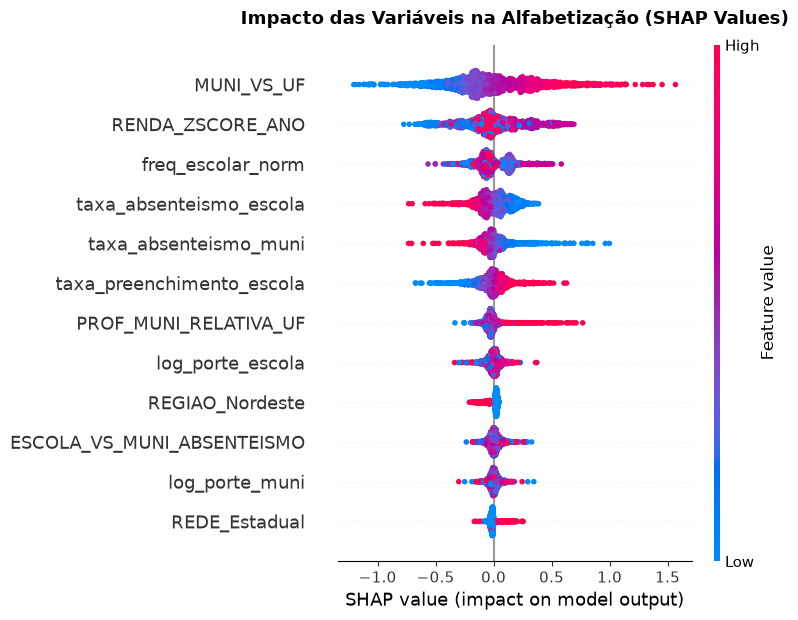

In [ ]:
import shap

# Usamos uma amostra de 2.000 alunos para o cálculo ser super rápido (menos de 5 segundos)
amostra_shap = X_test.sample(2000, random_state=42)
explainer = shap.TreeExplainer(modelo_lgbm_profundo)
shap_values = explainer.shap_values(amostra_shap)

# Se for binário, pega a classe 1 (Alfabetizado)
if isinstance(shap_values, list):
    valores = shap_values[1]
else:
    valores = shap_values

# Gráfico Beeswarm (O gráfico mais nobre de Machine Learning)
plt.figure(figsize=(10, 6))
shap.summary_plot(valores, amostra_shap, max_display=12, show=False)
plt.title("Impacto das Variáveis na Alfabetização (SHAP Values)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_summary_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()


Os pontos vermelhos indicam os numeros de maior valor da variavel quanto o azul de menor valor
o que está a esquerda indica menor probabilidade de alfabetização e o que está a direita indica maior probabilidade de alfabetização.

Então temos que quanto maior o GAP da Meta municipal, maior a probabilidade do aluno não estar alfabetizado, quanto menor o GAP da Meta, menor a probabilidade do aluno estar alfabetizado. 



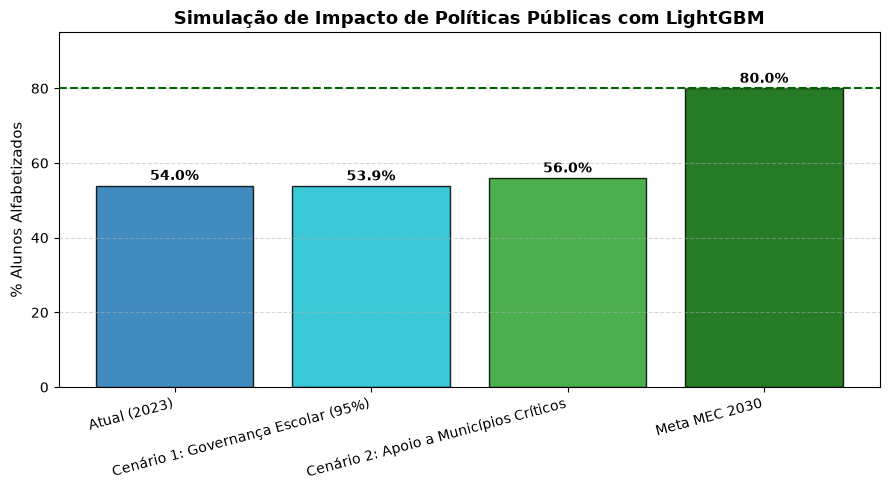

In [ ]:
# 1. Cenário Base (Atual)
taxa_base = modelo_lgbm_profundo.predict_proba(X_test)[:, 1].mean() * 100

# 2. Cenário A: Elevação de Governança Escolar (Taxa de preenchimento sobe para 95% em todas)
X_cenario_A = X_test.copy()
if "taxa_preenchimento_escola" in X_cenario_A.columns:
    X_cenario_A["taxa_preenchimento_escola"] = X_cenario_A["taxa_preenchimento_escola"].clip(lower=0.95)
taxa_A = modelo_lgbm_profundo.predict_proba(X_cenario_A)[:, 1].mean() * 100

# 3. Cenário B: Apoio aos Municípios Vulneráveis (Nenhum município fica abaixo de z-score = 0)
X_cenario_B = X_test.copy()
if "PROF_MUNI_ZSCORE" in X_cenario_B.columns:
    X_cenario_B["PROF_MUNI_ZSCORE"] = X_cenario_B["PROF_MUNI_ZSCORE"].clip(lower=0.0)
if "MUNI_VS_UF" in X_cenario_B.columns:
    X_cenario_B["MUNI_VS_UF"] = X_cenario_B["MUNI_VS_UF"].clip(lower=0.0)
taxa_B = modelo_lgbm_profundo.predict_proba(X_cenario_B)[:, 1].mean() * 100

# Gráfico de Barras de Cenários
cenarios = ["Atual (2023)", "Cenário 1: Governança Escolar (95%)", "Cenário 2: Apoio a Municípios Críticos", "Meta MEC 2030"]
valores = [taxa_base, taxa_A, taxa_B, 80.0]
cores = ["#1f77b4", "#17becf", "#2ca02c", "darkgreen"]

plt.figure(figsize=(9, 5))
barras = plt.bar(cenarios, valores, color=cores, alpha=0.85, edgecolor="black")
plt.axhline(80, color="darkgreen", linestyle="--", lw=1.5)
plt.ylabel("% Alunos Alfabetizados", fontsize=11)
plt.title("Simulação de Impacto de Políticas Públicas com LightGBM", fontsize=13, fontweight='bold')
plt.ylim(0, 95)
plt.xticks(rotation=15, ha="right", fontsize=10)

for b in barras:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 1.5, f"{h:.1f}%", ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("simulacao_politicas_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
df_erros = X_test.copy()
df_erros["Real"] = y_test.values
df_erros["Probabilidade"] = pred_probabilidades

# Alunos que superaram a previsão negativa do ambiente:
superacao = df_erros[(df_erros["Probabilidade"] <= 0.25) & (df_erros["Real"] == 1)]

# Alunos em ambiente favorável que ficaram para trás:
vulnerabilidade_oculta = df_erros[(df_erros["Probabilidade"] >= 0.80) & (df_erros["Real"] == 0)]

print(f"Casos de Superação encontrados: {len(superacao):,} alunos")
print(f"Casos de Vulnerabilidade Oculta: {len(vulnerabilidade_oculta):,} alunos")


Casos de Superação encontrados: 8,978 alunos
Casos de Vulnerabilidade Oculta: 10,152 alunos


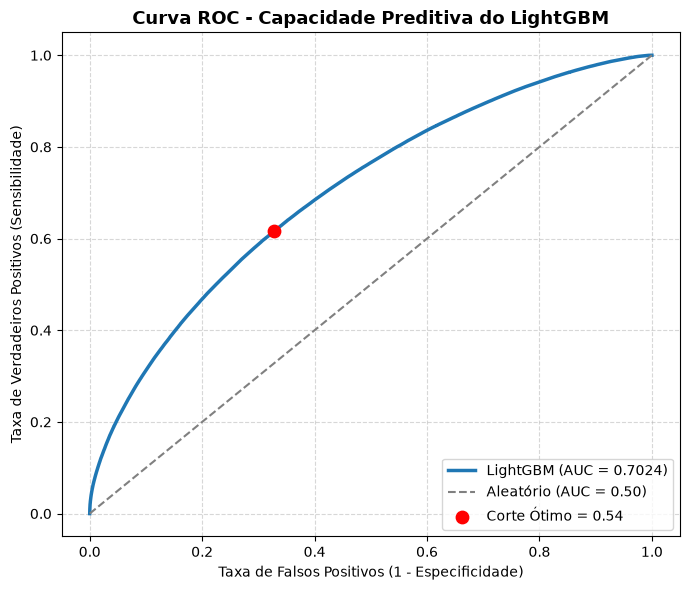

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, pred_probabilidades)
roc_auc = auc(fpr, tpr)

# Ponto ótimo pelo índice Youden (sensibilidade + especificidade máxima)
indice_otimo = np.argmax(tpr - fpr)
corte_otimo = thresholds[indice_otimo]

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'LightGBM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatório (AUC = 0.50)')
plt.scatter(fpr[indice_otimo], tpr[indice_otimo], color='red', s=80, zorder=5, 
            label=f'Corte Ótimo = {corte_otimo:.2f}')

plt.title("Curva ROC - Capacidade Preditiva do LightGBM", fontsize=13, fontweight='bold')
plt.xlabel("Taxa de Falsos Positivos (1 - Especificidade)")
plt.ylabel("Taxa de Verdadeiros Positivos (Sensibilidade)")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

# Cálculo ou Coleta Dinâmica dos Scores AUC-ROC 
# Se os modelos estiverem na memória, calculamos diretamente com X_test e y_test:
scores = {}

# Baseline: Classe Majoritária (por definição matemática, AUC = 0.50)
scores["Classe Majoritária (Baseline)"] = 0.5000

# Random Forest
if 'y_proba_rf' in locals():
    scores["Random Forest"] = roc_auc_score(y_test, y_proba_rf)
elif 'modelo_rf' in locals():
    scores["Random Forest"] = roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:, 1])

# XGBoost
if 'y_proba_xgb' in locals():
    scores["XGBoost"] = roc_auc_score(y_test, y_proba_xgb)
elif 'modelo_xgb' in locals():
    scores["XGBoost"] = roc_auc_score(y_test, modelo_xgb.predict_proba(X_test)[:, 1])

# LightGBM (Campeão)
if 'y_proba_prof' in locals():
    scores["LightGBM (Campeão)"] = roc_auc_score(y_test, y_proba_prof)
elif 'y_proba_lgbm' in locals():
    scores["LightGBM (Campeão)"] = roc_auc_score(y_test, y_proba_lgbm)
elif 'lgbm' in locals():
    scores["LightGBM (Campeão)"] = roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1])
elif 'modelo_lgbm_profundo' in locals():
    scores["LightGBM (Campeão)"] = roc_auc_score(y_test, modelo_lgbm_profundo.predict_proba(X_test)[:, 1])

# Converte para DataFrame e ordena do menor para o maior (para barra horizontal)
df_comp = pd.DataFrame(list(scores.items()), columns=["Modelo", "AUC_ROC"]).sort_values("AUC_ROC", ascending=True)

# Gráfico Executivo de Barras Horizontais 
plt.figure(figsize=(10, 5), dpi=150)

# Paleta de Cores com destaque no Campeão
cores = []
for m in df_comp["Modelo"]:
    if "LightGBM" in m:
        cores.append("#2ca02c")  # Verde para o Campeão
    elif "Baseline" in m or "Majoritária" in m:
        cores.append("#8c8c8c")  # Cinza neutro para o baseline
    else:
        cores.append("#1f77b4")  # Azul executivo para os demais

barras = plt.barh(df_comp["Modelo"], df_comp["AUC_ROC"], color=cores, height=0.55, alpha=0.88, edgecolor="black", lw=0.6)

# Linha de referência da adivinhação aleatória / baseline puro (0.50)
plt.axvline(0.50, color="gray", linestyle="--", lw=1.5, label="Aleatório / Baseline (0.50)")

# Rótulos de texto com o score exato ao lado de cada barra
for b in barras:
    w = b.get_width()
    is_campeao = w == df_comp["AUC_ROC"].max()
    texto = f"{w:.4f} ({w*100:.1f}%)" + (" 🏆" if is_campeao else "")
    cor_texto = "#1b5e20" if is_campeao else "#2c3e50"
    
    plt.text(
        w + 0.012, b.get_y() + b.get_height() / 2, texto,
        va='center', ha='left', fontsize=10, fontweight='bold', color=cor_texto
    )

plt.title("Comparativo de Desempenho dos Modelos — Métrica AUC-ROC", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("AUC-ROC Score (Área sob a Curva ROC)", fontsize=11, fontweight="bold")
plt.xlim(0.40, df_comp["AUC_ROC"].max() + 0.12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend(loc="lower right", frameon=True, fontsize=10)
plt.tight_layout()

# Salva em alta definição para o PowerPoint
plt.savefig("comparativo_roc_modelos_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()

print("Tabela Comparativa:")
display(df_comp.sort_values("AUC_ROC", ascending=False).reset_index(drop=True))


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Localização e Preparação dos Dados Municipais 
# Usamos resultado_metas_muni ou df_municipios (onde os nomes oficiais estão presentes)
if 'resultado_metas_muni' in locals() and 'NO_MUNICIPIO' in resultado_metas_muni.columns:
    df_fonte = resultado_metas_muni.copy()
    col_taxa = 'PC_ALUNO_ALFABETIZADO_2023' if 'PC_ALUNO_ALFABETIZADO_2023' in df_fonte.columns else 'PC_ALUNO_ALFABETIZADO'
elif 'df_municipios' in locals() and 'NO_MUNICIPIO' in df_municipios.columns:
    df_fonte = df_municipios[df_municipios.get('ID_TIPO_REDE', 5) == 5].copy()
    col_taxa = 'PC_ALUNO_ALFABETIZADO'
else:
    # Fallback caso os nomes estejam em df_municipios e as taxas em resultado_metas_muni
    df_fonte = resultado_metas_muni.copy()
    col_taxa = 'PC_ALUNO_ALFABETIZADO'

# Garante que a taxa seja numérica e remove nulos
df_fonte[col_taxa] = pd.to_numeric(df_fonte[col_taxa], errors='coerce')
df_muni_clean = df_fonte.dropna(subset=[col_taxa, 'NO_MUNICIPIO']).copy()

# Cria o rótulo legível: "Nome do Município - UF"
if 'SG_UF' in df_muni_clean.columns:
    df_muni_clean["LABEL"] = df_muni_clean["NO_MUNICIPIO"].str.title() + " - " + df_muni_clean["SG_UF"]
else:
    df_muni_clean["LABEL"] = df_muni_clean["NO_MUNICIPIO"].str.title()

# Agrupa por município (para evitar duplicatas de rede) pegando a média da taxa
df_ranking = df_muni_clean.groupby("LABEL", as_index=False)[col_taxa].mean()

# Seleção dos Top 10 e Bottom 10 
top10 = df_ranking.sort_values(by=col_taxa, ascending=True).tail(10)
bottom10 = df_ranking.sort_values(by=col_taxa, ascending=True).head(10)

#  Gráfico Executivo 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), dpi=150)
fig.suptitle("Disparidade Municipal: 10 Maiores vs 10 Menores Taxas de Alfabetização", 
             fontsize=15, fontweight="bold", y=0.98, color="#1a1a1a")

# Painel 1: Top 10 Melhores (Verde)
barras_top = ax1.barh(top10["LABEL"], top10[col_taxa], color="#2ca02c", height=0.6, alpha=0.88, edgecolor="black", lw=0.6)
ax1.axvline(80, color="darkgreen", linestyle="--", lw=1.5, label="Meta MEC 2030 (80%)")
ax1.set_xlim(0, 115)
ax1.set_title("🏆 Top 10 Municípios com Maior Alfabetização", fontsize=12, fontweight="bold", color="#1b5e20", pad=10)
ax1.set_xlabel("% Alunos Alfabetizados", fontsize=10, fontweight="bold")
ax1.grid(axis="x", linestyle="--", alpha=0.4)
ax1.legend(loc="lower right", fontsize=9)

for b in barras_top:
    w = b.get_width()
    ax1.text(w + 1.2, b.get_y() + b.get_height()/2, f"{w:.1f}%", 
             va='center', ha='left', fontsize=9, fontweight='bold', color="#1b5e20")

# Painel 2: Top 10 Piores (Vermelho)
barras_bot = ax2.barh(bottom10["LABEL"], bottom10[col_taxa], color="#d62728", height=0.6, alpha=0.88, edgecolor="black", lw=0.6)
ax2.axvline(80, color="darkgreen", linestyle="--", lw=1.5, label="Meta MEC 2030 (80%)")
ax2.set_xlim(0, 115)
ax2.set_title("⚠️ 10 Municípios com Menor Alfabetização (Atenção Urgente)", fontsize=12, fontweight="bold", color="#b71c1c", pad=10)
ax2.set_xlabel("% Alunos Alfabetizados", fontsize=10, fontweight="bold")
ax2.grid(axis="x", linestyle="--", alpha=0.4)
ax2.legend(loc="lower right", fontsize=9)

for b in barras_bot:
    w = b.get_width()
    ax2.text(w + 1.2, b.get_y() + b.get_height()/2, f"{w:.1f}%", 
             va='center', ha='left', fontsize=9, fontweight='bold', color="#b71c1c")

plt.tight_layout()

# Salva a imagem em alta definição para o slide
plt.savefig("top_bottom_10_municipios_powerpoint.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico salvo com sucesso como 'top_bottom_10_municipios_powerpoint.png'!")


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

for corte in [0.40, 0.50, 0.60]:
    pred_custom = (pred_probabilidades >= corte).astype(int)
    print("=" * 60)
    print(f" Ponto de Corte = {corte:.2f} ({corte*100:.0f}%)")
    print(f"Alunos previstos como alfabetizados: {pred_custom.sum():,} ({pred_custom.mean()*100:.1f}%)")
    print("=" * 60)
    print(classification_report(y_test, pred_custom, digits=4))


 Ponto de Corte = 0.40 (40%)
Alunos previstos como alfabetizados: 965,089 (79.2%)
              precision    recall  f1-score   support

           0     0.7012    0.3164    0.4361    560587
           1     0.6029    0.8851    0.7172    657446

    accuracy                         0.6233   1218033
   macro avg     0.6521    0.6007    0.5766   1218033
weighted avg     0.6482    0.6233    0.5878   1218033

 Ponto de Corte = 0.50 (50%)
Alunos previstos como alfabetizados: 708,051 (58.1%)
              precision    recall  f1-score   support

           0     0.6265    0.5699    0.5969    560587
           1     0.6595    0.7103    0.6839    657446

    accuracy                         0.6457   1218033
   macro avg     0.6430    0.6401    0.6404   1218033
weighted avg     0.6443    0.6457    0.6439   1218033

 Ponto de Corte = 0.60 (60%)
Alunos previstos como alfabetizados: 428,429 (35.2%)
              precision    recall  f1-score   support

           0     0.5637    0.7941    0.6594  